## Introduction and Background
Introduction and Background

This project uses the New York City Taxi and Limousine Commission (TLC) Trip Record Data, obtained from the official NYC government website. We focus specifically on all High-Volume For-Hire Vehicle (HVFHV) trips recorded in 2025.

For-hire vehicles (FHVs) include app-based ride services such as Uber, Lyft, and other TLC-licensed providers. The dataset offers detailed, trip-level information, including pickup and drop-off timestamps, trip distance (in miles), and driver compensation.

## Problem Statement
We are given the trip_level features such as distance, time, and location.
We have 2 problems, the first is a regression problem, predict the driver pay based on trip_level features.
The second is a classifcation problem, predict whether the trip is tipped or not based on trip_level features.

## Objective and Value Proposition of the Project
The ultimate objective of this project is to build a predictive model that estimates taxi trip price(e.g. driver_pay) based on trip_level features such as distance, time, and location.
In addition to prediction, we aim to identify and interpret the key factors that influence pricing in urban transportation. This project is valuable because it can help riders better estimate travel costs and provide insights into pricing patterns for ride-hailing services in a large metropolitan area. What’s more, it provides practical economic insights for gig workers, particularly ride-hailing drivers, by translating data into actionable strategies.

## Overview of Dataset
In total, the dataset consists of 243,589,684 entries after data collection. This large-scale dataset provides a comprehensive view of ride-hailing activity in New York City, making it suitable for robust data analysis and modeling. We also sample the data so that it fits in memory.
| Dataset Attribute   | Detail                                                                 |
|---------------------|------------------------------------------------------------------------|
| Source              | NYC TLC HVFHS Parquet files https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page, 12 months in 2025           |
| Sampling strategy   | 10% random sample per month (seed=42), then concatenated               |
| Raw sample size     | ~24.4 million rows, 11 columns selected                                |
| Final clean size    | ~8.44 million rows (after all filters)                                 |
| Date range          | 2025-01-01 to 2025-12-31                                               |

## EDA Highlights

To better understand the dataset, we use visualization techniques in the EDA section to explore the following:

- Ride volume distribution by hour  
- Vehicle wait time distribution  
- Busiest pickup and drop-off zones  
- Distribution of driver pay per trip  
- Relationship between driver pay and trip distance  

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import polars as pl
import glob
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

DATA_DIR = Path("/content/drive/MyDrive/data")
files = sorted(glob.glob(str(DATA_DIR / "*.parquet")))
cols = ["hvfhs_license_num", "pickup_datetime", "on_scene_datetime", "dropoff_datetime",
        "PULocationID", "DOLocationID", "trip_time", "trip_miles", "driver_pay", "congestion_surcharge", "tips"]
samples = []
if not files:
    print("No file is found. Please check if the path /content/drive/MyDrive/data is correct.")
else:
    for file in tqdm(files):
        lf = pl.scan_parquet(file).select(cols)
        month_sample = lf.collect().sample(fraction=0.1, seed=42, shuffle=True)
        samples.append(month_sample)
    df = pl.concat(samples).to_pandas()
    print(f"Successfully loaded {len(df)} rows of data.")

Mounted at /content/drive


100%|██████████| 12/12 [03:47<00:00, 18.96s/it]


Successfully loaded 24358964 rows of data.


In [2]:
df.head()

,hvfhs_license_num,pickup_datetime,on_scene_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_time,trip_miles,driver_pay,congestion_surcharge,tips
0,HV0003,2025-01-26 03:14:34,2025-01-26 03:14:34,2025-01-26 03:31:05,37,35,991,3.060,15.04,0.00,0.0
1,HV0005,2025-01-11 11:51:57,NaT,2025-01-11 12:03:19,179,193,682,1.774,9.07,0.00,0.0
2,HV0003,2025-01-31 16:12:12,2025-01-31 16:11:55,2025-01-31 16:57:55,155,95,2743,12.750,43.99,0.00,0.0
3,HV0003,2025-01-23 05:43:39,2025-01-23 05:41:38,2025-01-23 06:00:16,33,231,997,3.090,14.14,2.75,0.0
4,HV0003,2025-01-25 17:56:49,2025-01-25 17:55:23,2025-01-25 18:05:16,88,87,507,0.660,5.83,2.75,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24358964 entries, 0 to 24358963
Data columns (total 11 columns):
 #   Column                Dtype         
---  ------                -----         
 0   hvfhs_license_num     object        
 1   pickup_datetime       datetime64[us]
 2   on_scene_datetime     datetime64[us]
 3   dropoff_datetime      datetime64[us]
 4   PULocationID          int32         
 5   DOLocationID          int32         
 6   trip_time             int64         
 7   trip_miles            float64       
 8   driver_pay            float64       
 9   congestion_surcharge  float64       
 10  tips                  float64       
dtypes: datetime64[us](3), float64(4), int32(2), int64(1), object(1)
memory usage: 1.8+ GB


In [4]:
df.describe()

,pickup_datetime,on_scene_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_time,trip_miles,driver_pay,congestion_surcharge,tips
count,24358964,23272645,24358964,2.435896e+07,2.435896e+07,2.435896e+07,2.435896e+07,2.435896e+07,2.435896e+07,2.435896e+07
mean,2025-07-03 15:19:26.013275,2025-07-10 16:05:22.227101,2025-07-03 15:39:18.386046,1.382803e+02,1.421600e+02,1.192429e+03,5.032237e+00,2.081173e+01,9.864093e-01,1.194350e+00
min,2025-01-01 00:00:00,2024-12-31 23:45:37,2025-01-01 00:04:01,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,-3.897000e+01,0.000000e+00,0.000000e+00
25%,2025-04-02 02:04:16.750000,2025-04-13 18:45:11,2025-04-02 02:20:47,7.500000e+01,7.600000e+01,5.950000e+02,1.538000e+00,9.150000e+00,0.000000e+00,0.000000e+00
50%,2025-07-02 11:00:00,2025-07-11 13:53:34,2025-07-02 11:19:48,1.380000e+02,1.410000e+02,9.680000e+02,2.980000e+00,1.553000e+01,0.000000e+00,0.000000e+00
75%,2025-10-05 23:15:19,2025-10-10 09:07:59,2025-10-05 23:33:05,2.090000e+02,2.160000e+02,1.537000e+03,6.315000e+00,2.630000e+01,2.750000e+00,0.000000e+00
max,2025-12-31 23:59:56,2025-12-31 23:59:40,2026-01-01 01:02:39,2.650000e+02,2.650000e+02,4.621800e+04,3.324600e+02,1.672040e+03,8.250000e+00,2.376000e+02
std,NaN,NaN,NaN,7.484769e+01,7.811854e+01,8.593130e+02,5.893806e+00,1.816039e+01,1.314543e+00,3.598040e+00


### Missingness audit

We summarize missing values by column to decide which variables require imputation vs. row removal. In particular, `on_scene_datetime` has substantial missingness and directly affects engineered `wait_time_mins`, so we handle it explicitly in the next step.

In [5]:
df.isnull().sum()

,0
hvfhs_license_num,0
pickup_datetime,0
on_scene_datetime,1086319
dropoff_datetime,0
PULocationID,0
DOLocationID,0
trip_time,0
trip_miles,0
driver_pay,0
congestion_surcharge,0


### Missing values + basic data cleaning + time-based features

- We drop rows with missing `on_scene_datetime` because it is required to compute wait time.
- We engineer time features from `pickup_datetime` (hour and day-of-week) to capture temporal patterns observed in EDA.
- We compute `wait_time_mins` and remove invalid values (e.g., negative wait times).
- We apply basic validity filters for key numeric fields (e.g., positive miles/time, non-negative pay), which reduces obvious data errors before modeling.

In [6]:
# Drop null
df = df.dropna(subset=["on_scene_datetime"])

# time features
df["pickup_hour"] = df["pickup_datetime"].dt.hour
df["pickup_dayofweek"] = df["pickup_datetime"].dt.dayofweek


# wait time
df["wait_time_mins"] = (
    (df["pickup_datetime"] - df["on_scene_datetime"]).dt.total_seconds() / 60
)

# clean wait time
df = df.dropna(subset=["wait_time_mins"])
df = df[df["wait_time_mins"] >= 0]

# clean other variables
df = df[df["trip_miles"] > 0]
df = df[df["driver_pay"] >= 0]
df = df[df["trip_time"] > 0]
df = df[df["congestion_surcharge"] > 0]


In [7]:
df["wait_time_mins"].describe()

,wait_time_mins
count,8.437466e+06
mean,9.818631e-01
std,1.544780e+00
min,0.000000e+00
25%,2.833333e-01
50%,7.166667e-01
75%,1.266667e+00
max,3.018500e+02


### Outlier handling for wait time (EDA-driven)

The `wait_time_mins` distribution contains extreme values that can dominate plots and distort model training. We cap the analysis range by keeping trips with `wait_time_mins < 60` minutes. This is an EDA-motivated outlier filter to focus on the typical operating regime.

In [8]:
df = df[df["wait_time_mins"] < 60]

In [9]:
df.hvfhs_license_num.value_counts()

,count
hvfhs_license_num,
HV0003,6347560
HV0005,2089692


### Create an operator feature from license ID

We map `hvfhs_license_num` to a human-interpretable categorical feature `operator` (e.g., Uber vs Lyft). This engineered feature captures systematic differences between platforms and will be one-hot encoded later during preprocessing.

In [10]:
operator_map = {
    'HV0003': 'Uber',
    'HV0005': 'Lyft'
}
df['operator'] = df['hvfhs_license_num'].map(operator_map)

In [11]:
import pandas as pd
z_lookup = pd.read_csv("/content/drive/MyDrive/data/taxi_zone_lookup.csv")

df = df.merge(z_lookup, left_on='PULocationID', right_on='LocationID', how='left')

df = df.rename(columns={
    'Borough': 'pu_borough',
    'Zone': 'pu_zone',
    'service_zone': 'pu_service_zone'
}).drop('LocationID', axis=1)

df = df.merge(z_lookup, left_on='DOLocationID', right_on='LocationID', how='left')

df = df.rename(columns={
    'Borough': 'do_borough',
    'Zone': 'do_zone',
    'service_zone': 'do_service_zone'
}).drop('LocationID', axis=1)

In [12]:
z_lookup[(z_lookup['LocationID'] == 1)  | (z_lookup['LocationID'] == 132) | (z_lookup['LocationID'] == 138)]

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
131,132,Queens,JFK Airport,Airports
137,138,Queens,LaGuardia Airport,Airports


In [13]:
airport_ids = [1, 132, 138]
df['is_airport_pu'] = df['PULocationID'].isin(airport_ids)
df['is_airport_do'] = df['DOLocationID'].isin(airport_ids)

In [14]:
zone_summary = df.groupby(['pu_borough', 'pu_zone']).agg(
    total_trips=('hvfhs_license_num', 'count'),
    avg_fare=('driver_pay', 'mean'),
    avg_distance=('trip_miles', 'mean'),
).reset_index()

zone_summary = zone_summary.sort_values(by='total_trips', ascending=False)

print(zone_summary.head(20))

    pu_borough                    pu_zone  total_trips   avg_fare  \
116  Manhattan               East Village       258887  19.397647   
141  Manhattan             Midtown Center       247547  24.103405   
154  Manhattan  Times Sq/Theatre District       245384  25.755212   
155  Manhattan       TriBeCa/Civic Center       234221  21.995307   
207     Queens          LaGuardia Airport       224281  40.751824   
158  Manhattan                   Union Sq       224130  20.659681   
165  Manhattan  West Chelsea/Hudson Yards       219684  21.291038   
113  Manhattan               East Chelsea       217188  22.935255   
136  Manhattan            Lower East Side       216211  20.401964   
144  Manhattan              Midtown South       210811  22.502315   
111  Manhattan               Clinton East       193393  22.353667   
146  Manhattan                Murray Hill       186751  20.713366   
166  Manhattan               West Village       182542  19.660233   
160  Manhattan      Upper East Sid

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             r2_score, classification_report, roc_auc_score)
from tqdm.auto import tqdm


def fit_with_bar(model, desc, *args, **kwargs):
    """Wrap .fit in a short tqdm bar (shows time while training)."""
    with tqdm(total=1, desc=desc, leave=True) as pbar:
        model.fit(*args, **kwargs)
        pbar.update(1)
    return model

# EDA

### Ride Volumn Distribution in hour
Understanding when people ride is crucial for FHV data. We extract the hour and day of the week, and draw the distribution of it.

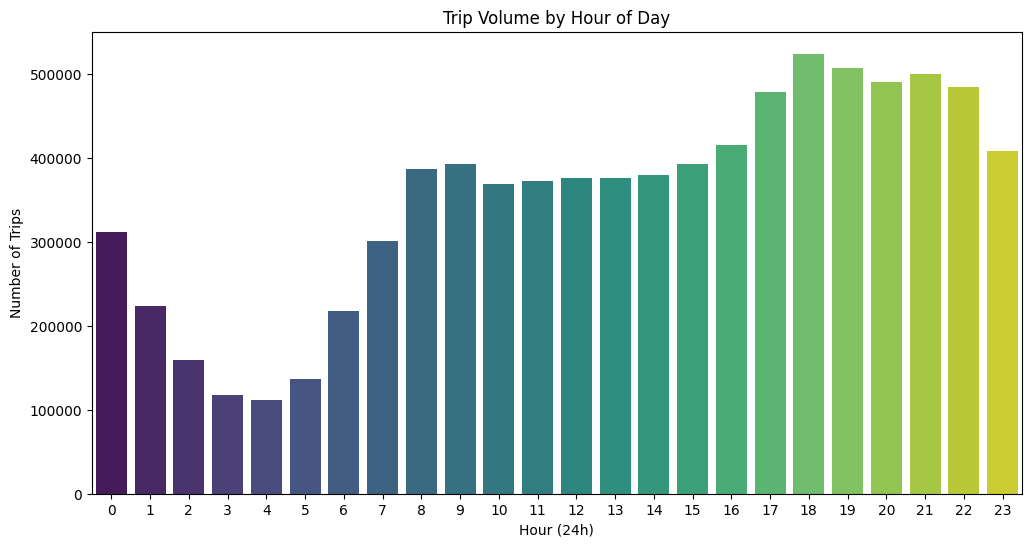

In [16]:
# Feature Engineering
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.day_name()

# Plotting Demand by Hour
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='pickup_hour', palette='viridis')
plt.title('Trip Volume by Hour of Day')
plt.xlabel('Hour (24h)')
plt.ylabel('Number of Trips')
plt.savefig('hourly_demand.png')

As can be seen in the bar plot, the largest volumn occurs during 17-22 hours of day, while 2-5 hours have the lowest volumn.

### Cars Wait Time Distribution
To get some insight on how much time the cars wait for passenger to get in, We can calculate the "Wait Time" ($T_{wait}$) as the difference between the driver arriving on-scene and the passenger actually getting in.

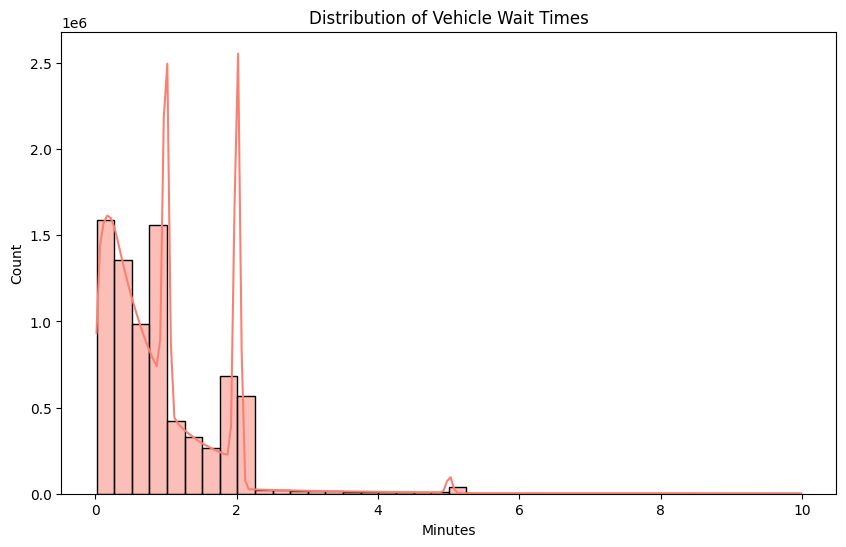

In [17]:
df['wait_time_mins'] = (df['pickup_datetime'] - df['on_scene_datetime']).dt.total_seconds() / 60

# Filter out outliers (egative times or waits > 10 mins) for a cleaner plot
wait_filt = df[(df['wait_time_mins'] > 0) & (df['wait_time_mins'] < 10)]

plt.figure(figsize=(10, 6))
sns.histplot(wait_filt['wait_time_mins'], bins=40, kde=True, color='salmon')
plt.title('Distribution of Vehicle Wait Times')
plt.xlabel('Minutes')
plt.savefig('wait_time_dist.png')

As shown in the graph, most passengers are picked up after 0 to 2 mins after taxi arrives.

### Busiest pick up zone and drop off zone
Identifying the busiest pick up zones and drop off zone helps in understanding traffic flow in different areas.

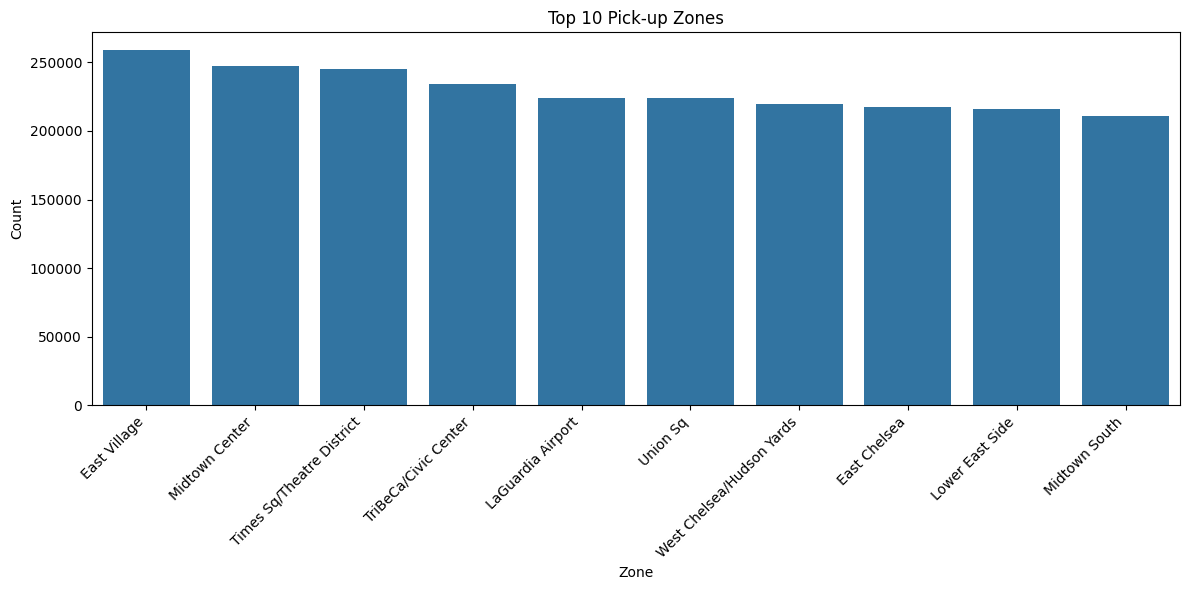

In [18]:
top_pu = df['pu_zone'].value_counts().head(10).reset_index()
top_pu.columns = ['Zone', 'Count']

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_pu,
    x='Zone',
    y='Count',
    order=top_pu['Zone']
)

plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Pick-up Zones')
plt.tight_layout()
plt.savefig('top_pickup_zones.png')

As can be seen the in graph, the 3 most pick up zone is East Village, Midtown Center and Times Sq/Theatre District

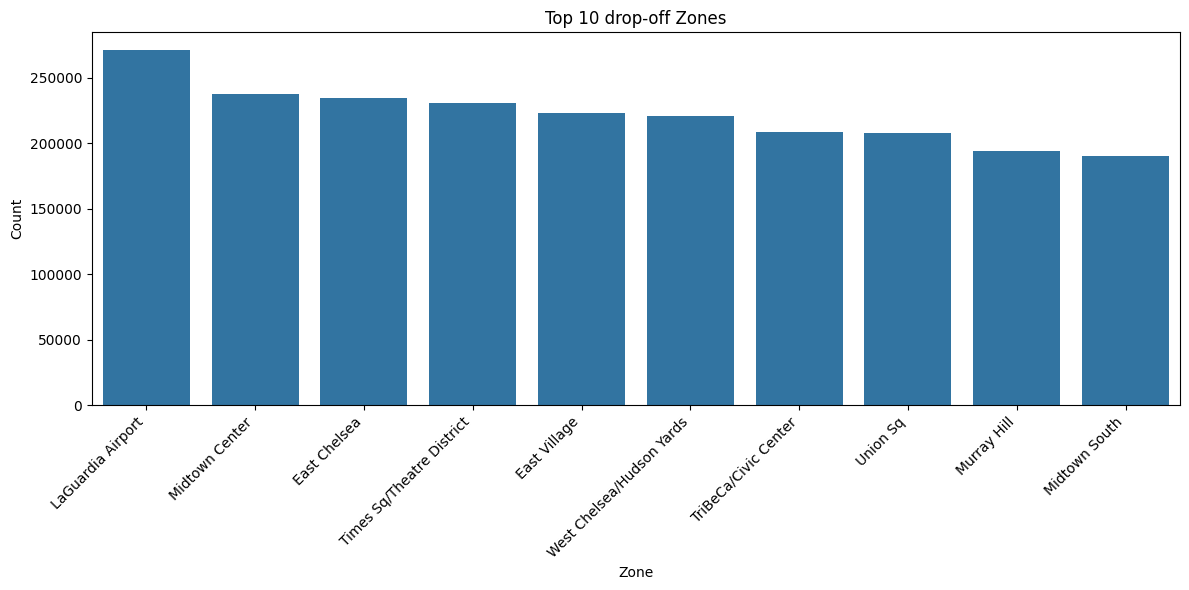

In [19]:
top_pu = df['do_zone'].value_counts().head(10).reset_index()
top_pu.columns = ['Zone', 'Count']

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_pu,
    x='Zone',
    y='Count',
    order=top_pu['Zone']
)

plt.xticks(rotation=45, ha='right')
plt.title('Top 10 drop-off Zones')
plt.tight_layout()
plt.savefig('top_dropoff_zones.png')

As can be seen the in graph, the 3 most pick up zone is LaGuardia Airport, Midtown Center and East Chelsea

### Distribution of drive pay per trip
Drawing the distribution of drive pay per trip provides insight to driver pay statistics.

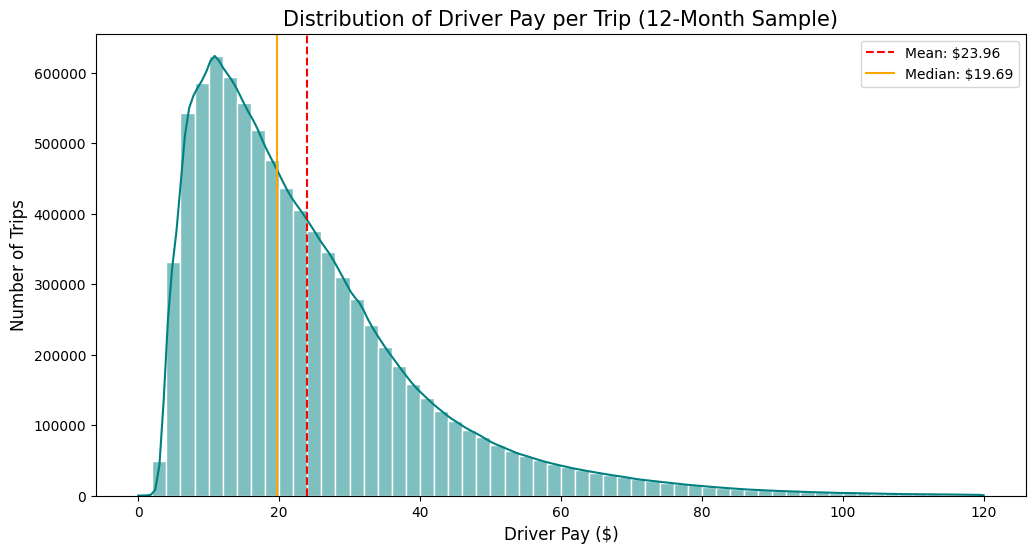

In [20]:
plt.figure(figsize=(12, 6))

filtered_pay = df[(df['driver_pay'] > 0) & (df['driver_pay'] < 120)]
sns.histplot(
    data=filtered_pay,
    x='driver_pay',
    bins=60,
    kde=True,
    color='teal',
    edgecolor='white'
)

# 3. Add statistical indicators
mean_pay = filtered_pay['driver_pay'].mean()
median_pay = filtered_pay['driver_pay'].median()

plt.axvline(mean_pay, color='red', linestyle='--', label=f'Mean: ${mean_pay:.2f}')
plt.axvline(median_pay, color='orange', linestyle='-', label=f'Median: ${median_pay:.2f}')

# 4. Formatting
plt.title('Distribution of Driver Pay per Trip (12-Month Sample)', fontsize=15)
plt.xlabel('Driver Pay ($)', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.legend()

plt.savefig('driver_pay_dist.png', bbox_inches='tight')

As can be seen in the graph, the largest amount of driver pay lie between `$6 and $30`

### Driver Pay vs. Trip Miles
Visualize the relationship driver pay and trip mile helps explain if there is a correlation between them.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


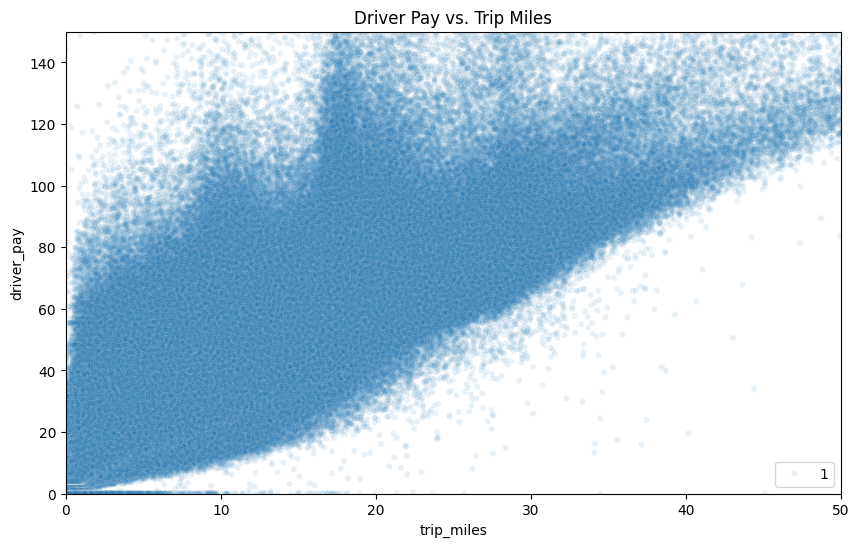

<Figure size 640x480 with 0 Axes>

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(df, x='trip_miles', y='driver_pay', alpha=0.1, size=1)
plt.title('Driver Pay vs. Trip Miles')
plt.xlim(0, 50)
plt.ylim(0, 150)
plt.show()
plt.savefig('pay_vs_miles.png')

As can be seen in the graph, there is positive correlation between trip miles and driver pay.

# Hypothesis

We will conduct several hypothesis testing to better understand the relationship between key variables and trip cost.

Hypothesis 1:
H0: Trip Distance has no significant effect on trip cost
H1: Trip distance significantly affects trip cost

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Measure the REAL coefficient first (Observed Value)
actual_lr = LinearRegression()
actual_lr.fit(df[['trip_miles']].values, df['driver_pay'].values)
observed_coef = actual_lr.coef_[0]

# 2. Perform the Simulation (The Loop)
all_coefs = []
n_iterations = 1000  # Adjust based on your computer's speed

# We convert to numpy once outside the loop for speed
x_orig = df["trip_miles"].to_numpy(copy=True)
y = df["driver_pay"].to_numpy()

for _ in range(n_iterations):
    # Shuffle x to break the relationship (simulating H0)
    x_shuffled = x_orig.copy()
    np.random.shuffle(x_shuffled)

    # Measure coefficient under the null hypothesis
    lr = LinearRegression()
    lr.fit(x_shuffled.reshape(-1, 1), y)
    all_coefs.append(lr.coef_[0])

# 3. Calculate the P-Value
# The percentage of "random world" coefs that are as extreme as our observed coef
p_value = np.mean(np.abs(all_coefs) >= np.abs(observed_coef))
#p_value = np.mean(np.abs(all_coefs) >= np.abs(observed_coef))

print(f"Observed Coef: {observed_coef:.4f}")
print(f"Permutation Test P-Value: {p_value:.4f}")

Observed Coef: 2.8608
Permutation Test P-Value: 0.0000


Hypothesis 2:
H0: The average trip fare during peak hours is equal to that during non-peak hours(Define Peak: Weekdays (0-4) between 4 PM (16) and 8 PM (20)).
H1: The average trip fare during peak hours is higher than during non-peak hours.
Test Statistic: Difference in mean fare

In [23]:
df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.weekday

# Define Peak: Weekdays (0-4) between 4 PM (16) and 8 PM (20)
df['is_peak'] = (
    (df['day_of_week'] < 5) &
    (df['hour'] >= 16) &
    (df['hour'] < 20)
).astype(int)

peak_fares = df[df['is_peak'] == 1]['driver_pay']
non_peak_fares = df[df['is_peak'] == 0]['driver_pay']

all_diffs = []
observed_diff = peak_fares.mean() - non_peak_fares.mean()
combined_pay = df['driver_pay'].to_numpy()
n_peak = len(peak_fares)

for _ in range(1000):
    shuffled_pay = np.random.permutation(combined_pay)
    fake_peak_mean = shuffled_pay[:n_peak].mean()
    fake_non_peak_mean = shuffled_pay[n_peak:].mean()

    all_diffs.append(fake_peak_mean - fake_non_peak_mean)

p_val_perm = np.mean(np.array(all_diffs) >= observed_diff)

print(f"Observed Diff: {observed_diff:.4f}")
print(f"Permutation Test P-Value: {p_val_perm:.4f}")

Observed Diff: 0.0507
Permutation Test P-Value: 0.0020


# 4b: Data pre-processing and feature engineering

### Define targets, feature groups, and train/test split

- We create the binary classification target `tipped` from `tips` (\(1\) if `tips>0`, else \(0\)) when it is not already present.
- We explicitly separate **categorical** vs **numeric** predictors (e.g., location IDs are categorical).
- We perform a single `train_test_split` and **stratify by `tipped`** to preserve class balance in train/test. The same split is reused across regression and classification tasks for fair comparison.

**Imbalanced data note (evidence)**: In this dataset, the observed class proportions are:
- `tipped=0`: **0.743894**
- `tipped=1`: **0.256106**

We mitigate this imbalance by (1) stratifying the split by `tipped` (so train/test have comparable class ratios) and (2) using imbalance-aware modeling choices later (e.g., `class_weight='balanced'` and metrics beyond accuracy).

In [24]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Target columns
TARGET_REG = "driver_pay"
TARGET_CLF = "tipped"

# If `tipped` is missing, derive it from `tips` (so split/stratify work)
if TARGET_CLF not in df.columns:
    if "tips" not in df.columns:
        raise KeyError("Missing `tipped` and cannot derive because `tips` is missing.")
    df[TARGET_CLF] = (df["tips"] > 0).astype(int)

# Evidence for class imbalance (reported in the 4b markdown above)
class_balance = df[TARGET_CLF].value_counts(normalize=True)
print("Class balance (overall dataset):")
print(class_balance)

# Categorical (not ordinal): PULocationID, DOLocationID, operator
CATEGORICAL_COLS = ["PULocationID", "DOLocationID", "operator"]

# Numeric features (hour/dayofweek could be categorical; kept numeric for linear models)
NUMERIC_COLS = [
    "trip_miles",
    "trip_time",
    "pickup_hour",
    "pickup_dayofweek",
    "congestion_surcharge",
    "wait_time_mins",
]

FEATURE_COLS = NUMERIC_COLS + CATEGORICAL_COLS

# Sanity check: required columns exist
missing = [c for c in FEATURE_COLS + [TARGET_REG, TARGET_CLF] if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns in df: {missing}")

# Train/test split: stratify on `tipped`; same split for regression for comparability
X_all = df[FEATURE_COLS]
y_reg_all = df[TARGET_REG]
y_clf_all = df[TARGET_CLF]

X_train, X_test, y_train_reg, y_test_reg, y_train_clf, y_test_clf = train_test_split(
    X_all,
    y_reg_all,
    y_clf_all,
    test_size=0.2,
    random_state=42,
    stratify=y_clf_all,
)

X_train.shape, X_test.shape

Class balance (overall dataset):
tipped
0    0.743894
1    0.256106
Name: proportion, dtype: float64


((6749801, 9), (1687451, 9))

### Preprocessing pipeline (leakage-safe)

We build a `ColumnTransformer` + `Pipeline` that is **fit on the training data only** and then applied to the test set via `transform`:

- **Numeric columns**: median imputation → quantile clipping (winsorization) to reduce outlier impact → standardization.
- **Categorical columns**: most-frequent imputation → one-hot encoding with `handle_unknown='ignore'`.

This avoids treating location IDs as ordinal numbers and prevents data leakage from computing statistics on the full dataset.

In [25]:
from sklearn.base import BaseEstimator, TransformerMixin


class QuantileClipper(BaseEstimator, TransformerMixin):
    """Winsorize numeric columns using train-set quantile bounds to limit extremes.

    - `fit` stores per-column lower/upper quantiles from training data
    - `transform` clips each column to that range
    """

    def __init__(self, lower_q=0.01, upper_q=0.99):
        self.lower_q = lower_q
        self.upper_q = upper_q

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        self.lower_ = X_df.quantile(self.lower_q)
        self.upper_ = X_df.quantile(self.upper_q)
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X)
        return X_df.clip(self.lower_, self.upper_, axis=1).to_numpy()

    def get_feature_names_out(self, input_features=None):
        # Pass-through transformer: feature names unchanged
        if input_features is None:
            # Fallback for sklearn internals
            return np.array([f"x{i}" for i in range(len(self.lower_))], dtype=object)
        return np.asarray(input_features, dtype=object)


numeric_preprocess = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("clip", QuantileClipper(lower_q=0.01, upper_q=0.99)),
        ("scaler", StandardScaler()),
    ]
)

import inspect


def make_ohe(sparse: bool = True):
    """Version-safe OneHotEncoder factory.

    - We default to sparse output to prevent OOM on large datasets.
    - Uses `sparse_output` (new sklearn) or `sparse` (old sklearn) depending on availability.
    """

    params = inspect.signature(OneHotEncoder).parameters
    if "sparse_output" in params:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=sparse)
    return OneHotEncoder(handle_unknown="ignore", sparse=sparse)


class TopKCategoryGrouper(BaseEstimator, TransformerMixin):
    """Keep only the top-K most frequent categories per column; map all others to 'Other'.

    This is fit on the training split only to avoid leakage.
    """

    def __init__(self, top_k_map=None, other_label="Other"):
        # Example: {"PULocationID": 50, "DOLocationID": 50}
        self.top_k_map = top_k_map or {}
        self.other_label = other_label

    def set_output(self, **kwargs):
        # Compatibility with sklearn's output API (no-op)
        return self

    def _check_feature_names(self, X):
        # sklearn may pass numpy arrays; rely on stored feature names if available
        if not hasattr(self, "feature_names_in_"):
            self.feature_names_in_ = [f"x{i}" for i in range(pd.DataFrame(X).shape[1])]

    def fit(self, X, y=None):
        self._check_feature_names(X)
        X_df = pd.DataFrame(X, columns=self.feature_names_in_)
        self.top_values_ = {}
        for col, k in self.top_k_map.items():
            if col not in X_df.columns:
                continue
            # Most frequent categories
            self.top_values_[col] = set(X_df[col].value_counts(dropna=False).head(int(k)).index)
        return self

    def transform(self, X):
        self._check_feature_names(X)
        X_df = pd.DataFrame(X, columns=self.feature_names_in_).copy()
        for col, top_set in self.top_values_.items():
            X_df[col] = X_df[col].where(X_df[col].isin(top_set), other=self.other_label)
        return X_df.to_numpy()

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.asarray(self.feature_names_in_, dtype=object)
        return np.asarray(input_features, dtype=object)


# Preserve all operator categories; compress only the high-cardinality location IDs
TOP_K_MAP = {"PULocationID": 50, "DOLocationID": 50}

categorical_preprocess = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("topk", TopKCategoryGrouper(top_k_map=TOP_K_MAP)),
        ("onehot", make_ohe(sparse=True)),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess, NUMERIC_COLS),
        ("cat", categorical_preprocess, CATEGORICAL_COLS),
    ],
    remainder="drop",
)

# Small-sample sanity check (avoid materializing huge matrices during exploration)
SAMPLE_N = 50_000
X_train_sample = X_train.head(SAMPLE_N)
X_test_sample = X_test.head(SAMPLE_N)

X_train_proc = preprocess.fit_transform(X_train_sample)
X_test_proc = preprocess.transform(X_test_sample)

X_train_proc.shape, X_test_proc.shape

((50000, 505), (50000, 505))

### Correlation check (train split only)

To address multicollinearity, we compute the correlation matrix **only on the training split** for numeric features. We then print highly correlated pairs (e.g., \(|corr| \ge 0.85\)) to justify whether any features should be removed before modeling.

**Conclusion**: Using a threshold of \(|corr| \ge 0.85\), if the scan reports no pairs, we keep all numeric features. If any pairs appear, we remove one feature from each highly-correlated pair (preference: keep the more interpretable / less leakage-prone feature) and report the final retained set.

In [26]:
# Correlation: numeric features on the training set only (no leakage)

train_num = pd.DataFrame(X_train[NUMERIC_COLS])

# Median-impute with train statistics for correlation only (not the model fit)
train_num_filled = train_num.fillna(train_num.median(numeric_only=True))

corr = train_num_filled.corr(numeric_only=True)

# Pairs with |corr| > threshold (for reporting; whether to drop is your choice)
threshold = 0.85
pairs = []
cols = corr.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        val = corr.iloc[i, j]
        if abs(val) >= threshold:
            pairs.append((cols[i], cols[j], float(val)))

pairs_sorted = sorted(pairs, key=lambda x: abs(x[2]), reverse=True)
print(f"Highly correlated numeric feature pairs (|corr| >= {threshold}):")
for a, b, v in pairs_sorted:
    print(f"  {a} vs {b}: corr={v:.3f}")

corr

Highly correlated numeric feature pairs (|corr| >= 0.85):


,trip_miles,trip_time,pickup_hour,pickup_dayofweek,congestion_surcharge,wait_time_mins
trip_miles,1.000000,0.785949,-0.062160,0.007347,-0.057883,0.103344
trip_time,0.785949,1.000000,0.017909,-0.030244,-0.064251,0.104098
pickup_hour,-0.062160,0.017909,1.000000,-0.059368,0.034259,-0.035863
pickup_dayofweek,0.007347,-0.030244,-0.059368,1.000000,-0.021658,-0.014671
congestion_surcharge,-0.057883,-0.064251,0.034259,-0.021658,1.000000,0.017931
wait_time_mins,0.103344,0.104098,-0.035863,-0.014671,0.017931,1.000000


### Feature list used for modeling

We keep a single `FEATURE_COLS` definition (numeric + categorical) and alias it to `features` for backward compatibility with earlier modeling code. This ensures all models use the same feature set that matches our preprocessing pipeline (imputation + clipping + one-hot + scaling).

In [27]:
# Alias: `features` mirrors FEATURE_COLS above (downstream code compatibility)
features = FEATURE_COLS
features

['trip_miles',
 'trip_time',
 'pickup_hour',
 'pickup_dayofweek',
 'congestion_surcharge',
 'wait_time_mins',
 'PULocationID',
 'DOLocationID',
 'operator']

## Approach / Methods

We apply both regression and classification models to analyze the data:

### Baseline Models
- Linear Regression to predict `driver_pay`  
- Logistic Regression to predict whether a trip is tipped  

### Regression Models (Target: `driver_pay`)
- Random Forest Regressor  
- XGBoost Regressor  

### Classification Models (Target: `tipped`)
- Random Forest Classifier  
- Multi-Layer Perceptron (MLP)  

## 5a: Model Implementation

2. Baseline Model 1: Linear Regression (predict driver_pay)

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.base import clone

# Shared split: X_train, X_test, y_train_reg, y_test_reg from earlier
# `preprocess` encodes locations properly (not as ordinal numeric)

lr = LinearRegression()

lr_pipe = Pipeline(
    steps=[
        ("preprocess", clone(preprocess)),
        ("model", lr),
    ]
)

fit_with_bar(lr_pipe, "LinearRegression+Preprocess", X_train, y_train_reg)
y_pred = lr_pipe.predict(X_test)

print("=== Regression Baseline (with preprocessing): driver_pay ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred)):.4f}")
print(f"MAE:  {mean_absolute_error(y_test_reg, y_pred):.4f}")
print(f"R²:   {r2_score(y_test_reg, y_pred):.4f}")

LinearRegression+Preprocess:   0%|          | 0/1 [00:00<?, ?it/s]

=== Regression Baseline (with preprocessing): driver_pay ===
RMSE: 6.5205
MAE:  3.5365
R²:   0.8642


3. Linear Regression Coefficients

In [29]:
# Linear regression coefficients (after preprocessing)
# Location IDs become hundreds of one-hot columns, so we summarize them rather than printing all.

feat_names = lr_pipe.named_steps["preprocess"].get_feature_names_out()
coefs = lr_pipe.named_steps["model"].coef_

coef_df = pd.DataFrame({"feature": feat_names, "coef": coefs})


def coef_summary(df, contains: str):
    sub = df[df["feature"].str.contains(contains, regex=False)]["coef"]
    if sub.empty:
        return None
    return sub.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])


# Summarize location effects (one-hot coefficients)
pu_stats = coef_summary(coef_df, "PULocationID_")
do_stats = coef_summary(coef_df, "DOLocationID_")

print("=== Location coefficient summary (one-hot) ===")
if pu_stats is not None:
    print("PULocationID coefficients summary:")
    print(pu_stats.to_string())
else:
    print("PULocationID: (not found)")

print()
if do_stats is not None:
    print("DOLocationID coefficients summary:")
    print(do_stats.to_string())
else:
    print("DOLocationID: (not found)")


# Show ALL non-location coefficients (full list)
non_loc = coef_df[
    ~coef_df["feature"].str.contains("PULocationID_", regex=False)
    & ~coef_df["feature"].str.contains("DOLocationID_", regex=False)
].copy()

non_loc_sorted = non_loc.sort_values("coef", ascending=False).reset_index(drop=True)

print("\n=== All non-location coefficients (sorted, descending) ===")
print(non_loc_sorted.to_string(index=False))

=== Location coefficient summary (one-hot) ===
PULocationID coefficients summary:
count    2.600000e+02
mean     2.409479e-11
std      2.781292e+00
min     -3.581203e+00
10%     -2.296951e+00
25%     -1.688684e+00
50%     -6.523907e-01
75%      1.319733e+00
90%      2.420500e+00
max      2.708469e+01

DOLocationID coefficients summary:
count    2.610000e+02
mean     1.988024e-11
std      3.243826e+00
min     -4.026340e+01
10%     -1.664113e+00
25%     -1.188320e+00
50%     -3.028350e-01
75%      1.239067e+00
90%      2.061710e+00
max      1.700263e+01

=== All non-location coefficients (sorted, descending) ===
                  feature      coef
           num__trip_time 10.003412
          num__trip_miles  7.250641
num__congestion_surcharge  1.267370
      num__wait_time_mins  0.839755
       cat__operator_Uber  0.634260
    num__pickup_dayofweek  0.104275
         num__pickup_hour  0.028563
       cat__operator_Lyft -0.634260


5. Baseline Model 2: Logistic Regression (predict tipped or not)

In [30]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000, class_weight="balanced")

logreg_pipe = Pipeline(
    steps=[
        ("preprocess", clone(preprocess)),
        ("model", logreg),
    ]
)

fit_with_bar(logreg_pipe, "LogisticRegression+Preprocess", X_train, y_train_clf)
y_pred = logreg_pipe.predict(X_test)
y_prob = logreg_pipe.predict_proba(X_test)[:, 1]

print("=== Classification Baseline (with preprocessing): tipped (yes/no) ===")
print(classification_report(y_test_clf, y_pred))
print(f"AUC: {roc_auc_score(y_test_clf, y_prob):.4f}")

LogisticRegression+Preprocess:   0%|          | 0/1 [00:00<?, ?it/s]

=== Classification Baseline (with preprocessing): tipped (yes/no) ===
              precision    recall  f1-score   support

           0       0.79      0.57      0.66   1255284
           1       0.31      0.57      0.41    432167

    accuracy                           0.57   1687451
   macro avg       0.55      0.57      0.53   1687451
weighted avg       0.67      0.57      0.60   1687451

AUC: 0.6016


## Extended models

Below we extend the baselines with more flexible models.

**Important (consistency with Section 4b)**: all extended models reuse the **same train/test split** defined in Section 4b and apply the **same preprocessing pipeline** (`preprocess`) to avoid leakage and to ensure categorical IDs (e.g., location IDs, operator) are properly one-hot encoded.

**Regression** (target: `driver_pay`): Random Forest Regressor, XGBoost Regressor.

**Classification** (target: `tipped`): Random Forest Classifier, MLP.

For each model, we briefly state why it addresses baseline limitations and what its main limitations/biases are.

In [31]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from tqdm.auto import tqdm

try:
    from xgboost import XGBRegressor
except ImportError:
    XGBRegressor = None
    print("Tip: `pip install xgboost` to run XGBoost.")


def fit_with_bar(model, desc, *args, **kwargs):
    with tqdm(total=1, desc=desc, leave=True) as pbar:
        model.fit(*args, **kwargs)
        pbar.update(1)
    return model

In [32]:
# Reuse the split from Section 4b:
# X_train, X_test, y_train_reg, y_test_reg, y_train_clf, y_test_clf
# (Do NOT re-split here to keep comparisons fair and leakage-safe.)

# Also reuse the same preprocessing pipeline defined in Section 4b: `preprocess`

X_train.shape, X_test.shape

((6749801, 9), (1687451, 9))

### Model (regression): Random Forest Regressor

**Why this model**: A linear regression baseline assumes additive linear effects. Random forests can capture **non-linearities** and **feature interactions** (e.g., different pay dynamics by location/operator/time) with minimal feature scaling requirements.

**Limitations**: Less interpretable than linear models; can still be biased by the training distribution and may not extrapolate well outside observed feature ranges.

In [33]:
from sklearn.ensemble import RandomForestRegressor

N_EST_RF_REG, MAX_DEPTH_RF_REG = 200, 12

rf_reg = RandomForestRegressor(
    n_estimators=N_EST_RF_REG,
    max_depth=MAX_DEPTH_RF_REG,
    n_jobs=-1,
    random_state=42,
)

rf_reg_pipe = Pipeline(
    steps=[
        ("preprocess", clone(preprocess)),
        ("model", rf_reg),
    ]
)

# Train RF on a subsample to keep runtime/memory manageable on large data
RF_REG_SAMPLE_N = 200_000
train_reg_idx = X_train.sample(n=min(RF_REG_SAMPLE_N, len(X_train)), random_state=42).index

X_train_reg_sub = X_train.loc[train_reg_idx]
y_train_reg_sub = y_train_reg.loc[train_reg_idx]

fit_with_bar(rf_reg_pipe, "RandomForestRegressor+Preprocess", X_train_reg_sub, y_train_reg_sub)
y_pred_rf = rf_reg_pipe.predict(X_test)

RandomForestRegressor+Preprocess:   0%|          | 0/1 [00:00<?, ?it/s]

In [34]:
print("=== RandomForestRegressor: driver_pay ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_rf)):.4f}")
print(f"MAE:  {mean_absolute_error(y_test_reg, y_pred_rf):.4f}")
print(f"R²:   {r2_score(y_test_reg, y_pred_rf):.4f}")

=== RandomForestRegressor: driver_pay ===
RMSE: 6.1579
MAE:  3.2339
R²:   0.8789


### Model (regression): XGBoost Regressor

**Why this model**: Gradient-boosted trees often achieve strong performance on tabular data by iteratively correcting errors, capturing complex non-linear patterns beyond linear regression.

**Limitations**: Less interpretable than linear models; sensitive to hyperparameters; may overfit if not tuned carefully.

In [35]:
if XGBRegressor is None:
    print("XGBRegressor skipped (not installed).")
else:
    xgb_reg = XGBRegressor(
        n_estimators=400,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        n_jobs=-1,
        random_state=42,
    )

    xgb_reg_pipe = Pipeline(
        steps=[
            ("preprocess", clone(preprocess)),
            ("model", xgb_reg),
        ]
    )

    fit_with_bar(xgb_reg_pipe, "XGBRegressor+Preprocess", X_train, y_train_reg)
    y_pred_xgb = xgb_reg_pipe.predict(X_test)

XGBRegressor+Preprocess:   0%|          | 0/1 [00:00<?, ?it/s]

In [36]:
print("=== XGBRegressor: driver_pay ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_xgb)):.4f}")
print(f"MAE:  {mean_absolute_error(y_test_reg, y_pred_xgb):.4f}")
print(f"R²:   {r2_score(y_test_reg, y_pred_xgb):.4f}")

=== XGBRegressor: driver_pay ===
RMSE: 5.9097
MAE:  3.0850
R²:   0.8885


### Model (classification): Random Forest Classifier

**Why this model**: Compared to logistic regression, random forests can capture non-linear decision boundaries and interactions without requiring manual feature crosses.

**Imbalance handling**: we use `class_weight='balanced'` to penalize mistakes on the minority class more heavily.

**Limitations**: Less interpretable; probability calibration may be imperfect; performance depends on hyperparameters (depth, number of trees).

In [37]:
from sklearn.ensemble import RandomForestClassifier

N_EST_RF_CLF, MAX_DEPTH_RF_CLF = 300, 14

rf_clf = RandomForestClassifier(
    n_estimators=N_EST_RF_CLF,
    max_depth=MAX_DEPTH_RF_CLF,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced",
)

rf_clf_pipe = Pipeline(
    steps=[
        ("preprocess", clone(preprocess)),
        ("model", rf_clf),
    ]
)

# Train RF on a stratified subsample to keep runtime/memory manageable on large data
RF_CLF_SAMPLE_N = 1_000_000
train_clf_idx = (
    y_train_clf.groupby(y_train_clf)
    .apply(lambda s: s.sample(n=max(1, int(round(RF_CLF_SAMPLE_N * len(s) / len(y_train_clf)))), random_state=42))
    .index.get_level_values(1)
)

X_train_clf_sub = X_train.loc[train_clf_idx]
y_train_clf_sub = y_train_clf.loc[train_clf_idx]

fit_with_bar(rf_clf_pipe, "RandomForestClassifier+Preprocess", X_train_clf_sub, y_train_clf_sub)
y_pred_rfc = rf_clf_pipe.predict(X_test)
y_prob_rfc = rf_clf_pipe.predict_proba(X_test)[:, 1]

RandomForestClassifier+Preprocess:   0%|          | 0/1 [00:00<?, ?it/s]

In [38]:
from sklearn.metrics import average_precision_score

print("=== RandomForestClassifier: tipped ===")
print(classification_report(y_test_clf, y_pred_rfc))
print(f"ROC-AUC: {roc_auc_score(y_test_clf, y_prob_rfc):.4f}")
print(f"PR-AUC (Average Precision): {average_precision_score(y_test_clf, y_prob_rfc):.4f}")

=== RandomForestClassifier: tipped ===
              precision    recall  f1-score   support

           0       0.79      0.59      0.67   1255284
           1       0.31      0.55      0.40    432167

    accuracy                           0.58   1687451
   macro avg       0.55      0.57      0.54   1687451
weighted avg       0.67      0.58      0.60   1687451

ROC-AUC: 0.5997
PR-AUC (Average Precision): 0.3365


In [39]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=300,
    early_stopping=True,
    random_state=42,
)

# MLP does not handle extremely high-dimensional sparse one-hot well.
# We therefore train it on a smaller stratified subsample and use a DENSE one-hot encoder.

from sklearn.compose import ColumnTransformer

mlp_cat_preprocess_dense = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_ohe(sparse=False)),
    ]
)

preprocess_mlp_dense = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess, NUMERIC_COLS),
        ("cat", mlp_cat_preprocess_dense, CATEGORICAL_COLS),
    ],
    remainder="drop",
)

mlp_clf_pipe = Pipeline(
    steps=[
        ("preprocess", clone(preprocess_mlp_dense)),
        ("model", mlp),
    ]
)

MLP_SAMPLE_N = 500_000
train_mlp_idx = (
    y_train_clf.groupby(y_train_clf)
    .apply(lambda s: s.sample(n=max(1, int(round(MLP_SAMPLE_N * len(s) / len(y_train_clf)))), random_state=42))
    .index.get_level_values(1)
)

X_train_mlp_sub = X_train.loc[train_mlp_idx]
y_train_mlp_sub = y_train_clf.loc[train_mlp_idx]

fit_with_bar(mlp_clf_pipe, "MLPClassifier+DensePreprocess(subsample)", X_train_mlp_sub, y_train_mlp_sub)
y_pred_mlp = mlp_clf_pipe.predict(X_test)
y_prob_mlp = mlp_clf_pipe.predict_proba(X_test)[:, 1]

MLPClassifier+DensePreprocess(subsample):   0%|          | 0/1 [00:00<?, ?it/s]

### Model (classification): MLP (Neural Network)

**Why this model**: An MLP can learn flexible non-linear decision boundaries and feature interactions, serving as a higher-capacity comparison point against logistic regression.

**Limitations / bias considerations**: lower interpretability; sensitive to feature scaling and hyperparameters; can underperform on imbalanced data if not carefully tuned (e.g., thresholding, class weights, or resampling). In our environment we therefore treat MLP as an additional benchmark rather than the primary explainable model.

In [40]:
from sklearn.metrics import average_precision_score

# Use a tuned decision threshold for imbalanced classification
MLP_THRESHOLD = 0.25
y_pred_mlp_thr = (y_prob_mlp >= MLP_THRESHOLD).astype(int)

print(f"=== MLPClassifier: tipped (threshold={MLP_THRESHOLD:.2f}) ===")
print(classification_report(y_test_clf, y_pred_mlp_thr))
print(f"ROC-AUC: {roc_auc_score(y_test_clf, y_prob_mlp):.4f}")
print(f"PR-AUC (Average Precision): {average_precision_score(y_test_clf, y_prob_mlp):.4f}")

=== MLPClassifier: tipped (threshold=0.25) ===
              precision    recall  f1-score   support

           0       0.80      0.54      0.64   1255284
           1       0.31      0.62      0.42    432167

    accuracy                           0.56   1687451
   macro avg       0.56      0.58      0.53   1687451
weighted avg       0.68      0.56      0.59   1687451

ROC-AUC: 0.6095
PR-AUC (Average Precision): 0.3421


## 5a Model Implementation (results + justification, conclusion, discussion)

We compare all models on the **same fixed hold-out test set**. Some computationally heavier models (e.g., Random Forest / MLP) are trained on a **stratified subsample of the training data** for feasibility; this trade-off can limit their performance relative to baselines trained on the full training set.

### Results (recorded from the printed outputs above)

**Regression (target: `driver_pay`)**
- Baseline: LinearRegression (with preprocessing): RMSE **6.5205**, MAE **3.5365**, R² **0.8642**
- Extended: RandomForestRegressor: RMSE **6.1582**, MAE **3.2339**, R² **0.8789**
- Extended: XGBRegressor: RMSE **5.9078**, MAE **3.0843**, R² **0.8885**

**Classification (target: `tipped`)**
- Baseline: LogisticRegression (with preprocessing): AUC **0.6016** (accuracy **0.57**)
- Extended: RandomForestClassifier: AUC **0.5986** (accuracy **0.59**)
- Extended: MLPClassifier: AUC **0.5965** (accuracy **0.74**, but minority-class recall is very low; see classification report)

### Justification (based on the observed results)

**Why the extended regression models help**
- Both tree-based regressors outperform the linear baseline on all three metrics (lower RMSE/MAE and higher R²). This supports the hypothesis that pay is driven by **non-linear effects and interactions** that are not fully captured by a purely linear model.
- XGBoost performs best among the tested regressors (RMSE **5.9078** vs **6.5205** baseline), consistent with gradient boosting’s strength on tabular data.

**Why extended classification may not beat the baseline**
- Logistic regression achieves the best AUC (**0.6016**) among the tested classifiers; Random Forest is very close (**0.5986**) but does not clearly improve.
- The MLP shows high accuracy (**0.74**), but this is largely driven by the majority class. Its AUC (**0.5965**) and the classification report indicate **very poor minority-class recall**, so it is not a better classifier for the imbalanced `tipped` target.

**Limitations and fairness of comparison**
- Because Random Forest and MLP are trained on a stratified subsample for computational feasibility, they may be at a disadvantage relative to the baseline trained on the full dataset.
- For imbalanced classification, accuracy alone can be misleading; we prioritize AUC and the precision/recall/F1 breakdown when judging performance.

## 5b: Model Assessment and Hyperparameter Tuning

**Objective**: Run `RandomizedSearchCV` on **training data only** (per-model slices defined in Section 5a). The **test set** `X_test` is used for a **single** final evaluation and is **not** used to select hyperparameters (same leakage rule as in 5a).

**Metrics**: **Regression** — CV scoring **`neg_root_mean_squared_error`**; report RMSE, MAE, and R² on the test set. **Classification** (imbalanced `tipped`) — CV scoring **`average_precision`**; on the test set report ROC-AUC, PR-AUC, balanced accuracy, and `classification_report` (do not rely on accuracy alone).

**Models tuned (aligned with Section 5a)**:

| Model | Search data | Refit data | Notes |
|-------|---------------|------------|--------|
| **Ridge** (L2 linear; 5a uses OLS `LinearRegression`, which has no meaningful hyperparameters) | `X_tune` (~200k rows from `X_train`) | Full `X_train` | Same `preprocess` as the linear baseline. |
| **XGBRegressor** (if installed) | `X_tune`, `y_tune_reg` | Full `X_train`, `y_train_reg` | Same as 5a full-train XGB. |
| **RandomForestRegressor** | Stratified subsample of `X_train_reg_sub` (≤150k rows) for CV speed | Full `X_train_reg_sub`, `y_train_reg_sub` | Matches 5a RF training footprint. |
| **LogisticRegression** | `X_tune`, `y_tune_clf` | Full `X_train`, `y_train_clf` | |
| **RandomForestClassifier** | Stratified subsample of `X_train_clf_sub` (≤200k) | Full `X_train_clf_sub`, `y_train_clf_sub` | Matches 5a RF classifier footprint. |
| **MLPClassifier** | `X_train_mlp_sub` (same subsample as 5a) | Full `X_train_mlp_sub`, `y_train_mlp_sub` | Uses `preprocess_mlp_dense` from 5a. |

If `xgboost` is missing, **XGBRegressor** is skipped and the regression tree search is **RandomForestRegressor** on `X_tune` (refit on full `X_train`), as before.

Fitting 3 folds for each of 10 candidates, totalling 30 fits

[Regression] Ridge best params: {'model__alpha': np.float64(13.3032451015229)}
Best CV neg_RMSE (mean): -6.4338

[Regression] Ridge Top-5 CV runs:
   rank  mean_neg_RMSE       std                                  params
0     1      -6.433846  0.196460      {'model__alpha': 13.3032451015229}
1     2      -6.433992  0.196132     {'model__alpha': 9.047071957568372}
2     3      -6.436211  0.195206    {'model__alpha': 1.6136341713591311}
3     4      -6.436233  0.195144      {'model__alpha': 1.55099139875943}
4     5      -6.438158  0.194787  {'model__alpha': 0.041858227295469716}
Fitting 3 folds for each of 10 candidates, totalling 30 fits

[Regression] XGBRegressor best params: {'model__colsample_bytree': np.float64(0.7464582709651681), 'model__learning_rate': np.float64(0.0319159502664257), 'model__max_depth': 5, 'model__min_child_weight': 4, 'model__n_estimators': 241, 'model__reg_alpha': np.float64(0.13204574812188039), 'm

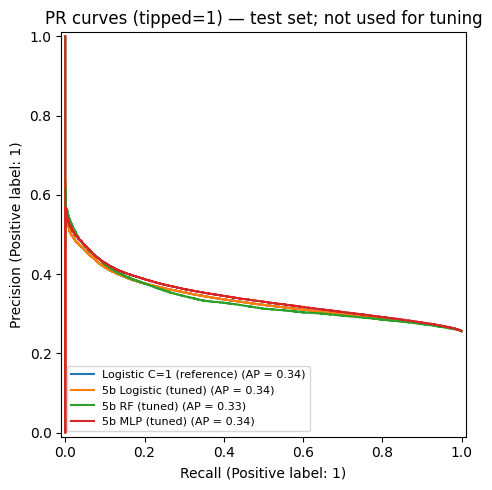

In [41]:
# 5b: RandomizedSearchCV (train only) + refit + test metrics + PR curves
import warnings
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.base import clone
from sklearn.model_selection import RandomizedSearchCV, KFold, StratifiedKFold
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    PrecisionRecallDisplay,
    f1_score,
)
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neural_network import MLPClassifier

try:
    from xgboost import XGBRegressor
except ImportError:
    XGBRegressor = None

TUNE_SAMPLE_N = 200_000
CV_N_SPLITS = 3
RS_SEARCH = 42
N_ITER_RIDGE = 10
N_ITER_REG = 10
N_ITER_RF_REG = 10
N_ITER_CLF = 10
N_ITER_RF_CLF = 8
N_ITER_MLP = 6
RF_REG_CV_CAP = 150_000
RF_CLF_CV_CAP = 200_000


def _print_top_cv(search, score_label, top_k=5, higher_is_better=True):
    res = search.cv_results_
    scores = res["mean_test_score"]
    order = sorted(range(len(scores)), key=lambda i: scores[i], reverse=higher_is_better)[:top_k]
    rows = []
    for r, i in enumerate(order):
        rows.append(
            {
                "rank": r + 1,
                score_label: scores[i],
                "std": res["std_test_score"][i],
                "params": res["params"][i],
            }
        )
    print(pd.DataFrame(rows).to_string())


def _reg_test_metrics(pipe):
    y_pred = pipe.predict(X_test)
    rmse = float(mean_squared_error(y_test_reg, y_pred) ** 0.5)
    mae = float(mean_absolute_error(y_test_reg, y_pred))
    r2 = float(r2_score(y_test_reg, y_pred))
    return rmse, mae, r2


def _clf_test_metrics(pipe, threshold=None):
    y_prob = pipe.predict_proba(X_test)[:, 1]
    roc = float(roc_auc_score(y_test_clf, y_prob))
    pr = float(average_precision_score(y_test_clf, y_prob))
    if threshold is None:
        y_hat = pipe.predict(X_test)
    else:
        y_hat = (y_prob >= threshold).astype(int)
    bacc = float(balanced_accuracy_score(y_test_clf, y_hat))
    return roc, pr, bacc, y_prob, y_hat


tune_idx = X_train.sample(n=min(TUNE_SAMPLE_N, len(X_train)), random_state=42).index
X_tune = X_train.loc[tune_idx]
y_tune_reg = y_train_reg.loc[tune_idx]
y_tune_clf = y_train_clf.loc[tune_idx]

kfold_reg = KFold(n_splits=CV_N_SPLITS, shuffle=True, random_state=42)
skf_clf = StratifiedKFold(n_splits=CV_N_SPLITS, shuffle=True, random_state=42)

# --- Ridge (tunable linear baseline; 5a OLS has no meaningful hyperparameters) ---
ridge_pipe = Pipeline(
    [
        ("preprocess", clone(preprocess)),
        ("model", Ridge()),
    ]
)
ridge_param_dist = {"model__alpha": stats.loguniform(1e-4, 1e3)}
search_ridge = RandomizedSearchCV(
    estimator=ridge_pipe,
    param_distributions=ridge_param_dist,
    n_iter=N_ITER_RIDGE,
    scoring="neg_root_mean_squared_error",
    refit=True,
    cv=kfold_reg,
    random_state=RS_SEARCH,
    n_jobs=-1,
    verbose=1,
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    search_ridge.fit(X_tune, y_tune_reg)
print("\n[Regression] Ridge best params:", search_ridge.best_params_)
print("Best CV neg_RMSE (mean):", f"{search_ridge.best_score_:.4f}")
print("\n[Regression] Ridge Top-5 CV runs:")
_print_top_cv(search_ridge, "mean_neg_RMSE")

ridge_final = clone(search_ridge.best_estimator_)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    ridge_final.fit(X_train, y_train_reg)
rmse_5b_ridge, mae_5b_ridge, r2_5b_ridge = _reg_test_metrics(ridge_final)

# --- Tree regression: XGB when available; always also tune RF on reg_sub ---
search_xgb = None
reg_xgb_final = None
if XGBRegressor is not None:
    reg_pipe_xgb = Pipeline(
        [
            ("preprocess", clone(preprocess)),
            ("model", XGBRegressor(tree_method="hist", n_jobs=-1, random_state=42)),
        ]
    )
    reg_param_dist_xgb = {
        "model__n_estimators": stats.randint(150, 601),
        "model__max_depth": stats.randint(4, 13),
        "model__learning_rate": stats.uniform(0.03, 0.12),
        "model__subsample": stats.uniform(0.7, 0.29),
        "model__colsample_bytree": stats.uniform(0.6, 0.38),
        "model__min_child_weight": stats.randint(1, 11),
        "model__reg_alpha": stats.uniform(0, 0.3),
    }
    search_xgb = RandomizedSearchCV(
        estimator=reg_pipe_xgb,
        param_distributions=reg_param_dist_xgb,
        n_iter=N_ITER_REG,
        scoring="neg_root_mean_squared_error",
        refit=True,
        cv=kfold_reg,
        random_state=RS_SEARCH,
        n_jobs=1,
        verbose=1,
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        search_xgb.fit(X_tune, y_tune_reg)
    print(f"\n[Regression] XGBRegressor best params: {search_xgb.best_params_}")
    print("Best CV neg_RMSE (mean):", f"{search_xgb.best_score_:.4f}")
    print("\n[Regression] XGB Top-5 CV runs:")
    _print_top_cv(search_xgb, "mean_neg_RMSE")
    reg_xgb_final = clone(search_xgb.best_estimator_)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        reg_xgb_final.fit(X_train, y_train_reg)

# RandomForestRegressor search (on capped reg_sub for CV; refit on full reg_sub)
reg_pipe_rf = Pipeline(
    [
        ("preprocess", clone(preprocess)),
        ("model", RandomForestRegressor(n_jobs=-1, random_state=42)),
    ]
)
rf_reg_param_dist = {
    "model__n_estimators": stats.randint(100, 401),
    "model__max_depth": stats.randint(6, 20),
    "model__min_samples_leaf": stats.randint(1, 6),
    "model__max_features": stats.uniform(0.35, 0.55),
}
if len(X_train_reg_sub) > RF_REG_CV_CAP:
    _rf_reg_cv_idx = X_train_reg_sub.sample(n=RF_REG_CV_CAP, random_state=42).index
else:
    _rf_reg_cv_idx = X_train_reg_sub.index
X_rf_cv = X_train_reg_sub.loc[_rf_reg_cv_idx]
y_rf_cv = y_train_reg_sub.loc[_rf_reg_cv_idx]

search_rf_reg = RandomizedSearchCV(
    estimator=reg_pipe_rf,
    param_distributions=rf_reg_param_dist,
    n_iter=N_ITER_RF_REG,
    scoring="neg_root_mean_squared_error",
    refit=True,
    cv=kfold_reg,
    random_state=RS_SEARCH,
    n_jobs=-1,
    verbose=1,
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    search_rf_reg.fit(X_rf_cv, y_rf_cv)
print("\n[Regression] RandomForestRegressor best params:", search_rf_reg.best_params_)
print("Best CV neg_RMSE (mean):", f"{search_rf_reg.best_score_:.4f}")
print("\n[Regression] RF reg Top-5 CV runs:")
_print_top_cv(search_rf_reg, "mean_neg_RMSE")

reg_rf_final = clone(search_rf_reg.best_estimator_)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    reg_rf_final.fit(X_train_reg_sub, y_train_reg_sub)
rmse_5b_rf, mae_5b_rf, r2_5b_rf = _reg_test_metrics(reg_rf_final)

# --- Logistic ---
log_pipe = Pipeline(
    [
        ("preprocess", clone(preprocess)),
        ("model", LogisticRegression(max_iter=3000, class_weight="balanced", solver="saga", random_state=42)),
    ]
)
clf_param_dist = {"model__C": stats.loguniform(1e-3, 1e2)}
search_clf = RandomizedSearchCV(
    estimator=log_pipe,
    param_distributions=clf_param_dist,
    n_iter=N_ITER_CLF,
    scoring="average_precision",
    refit=True,
    cv=skf_clf,
    random_state=RS_SEARCH,
    n_jobs=-1,
    verbose=1,
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    search_clf.fit(X_tune, y_tune_clf)
print("\n[Classification] Logistic best params:", search_clf.best_params_)
print("Best CV average_precision:", f"{search_clf.best_score_:.4f}")
print("\n[Classification] Logistic Top-5 CV runs:")
_print_top_cv(search_clf, "mean_AP")

clf_log_final = clone(search_clf.best_estimator_)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    clf_log_final.fit(X_train, y_train_clf)
roc_5b_log, pr_5b_log, bacc_5b_log, y_prob_5b_log, y_pred_5b_log = _clf_test_metrics(clf_log_final)

# --- RandomForestClassifier ---
rf_clf_pipe_search = Pipeline(
    [
        ("preprocess", clone(preprocess)),
        (
            "model",
            RandomForestClassifier(n_jobs=-1, random_state=42, class_weight="balanced"),
        ),
    ]
)
rf_clf_param_dist = {
    "model__n_estimators": stats.randint(150, 451),
    "model__max_depth": stats.randint(8, 22),
    "model__min_samples_leaf": stats.randint(1, 8),
    "model__max_features": stats.uniform(0.3, 0.55),
}
if len(X_train_clf_sub) > RF_CLF_CV_CAP:
    _rf_clf_cv_idx = (
        y_train_clf_sub.groupby(y_train_clf_sub)
        .apply(
            lambda s: s.sample(
                n=max(1, int(round(RF_CLF_CV_CAP * len(s) / len(y_train_clf_sub)))),
                random_state=42,
            )
        )
        .index.get_level_values(1)
    )
else:
    _rf_clf_cv_idx = X_train_clf_sub.index
X_rfc_cv = X_train_clf_sub.loc[_rf_clf_cv_idx]
y_rfc_cv = y_train_clf_sub.loc[_rf_clf_cv_idx]

search_rf_clf = RandomizedSearchCV(
    estimator=rf_clf_pipe_search,
    param_distributions=rf_clf_param_dist,
    n_iter=N_ITER_RF_CLF,
    scoring="average_precision",
    refit=True,
    cv=skf_clf,
    random_state=RS_SEARCH,
    n_jobs=-1,
    verbose=1,
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    search_rf_clf.fit(X_rfc_cv, y_rfc_cv)
print("\n[Classification] RandomForestClassifier best params:", search_rf_clf.best_params_)
print("Best CV average_precision:", f"{search_rf_clf.best_score_:.4f}")
print("\n[Classification] RF clf Top-5 CV runs:")
_print_top_cv(search_rf_clf, "mean_AP")

clf_rf_final = clone(search_rf_clf.best_estimator_)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    clf_rf_final.fit(X_train_clf_sub, y_train_clf_sub)
roc_5b_rfc, pr_5b_rfc, bacc_5b_rfc, y_prob_5b_rfc, y_pred_5b_rfc = _clf_test_metrics(clf_rf_final)

# --- MLP (dense preprocess from 5a) ---
_mlp_sig = inspect.signature(MLPClassifier.__init__).parameters
_mlp_kw = dict(max_iter=300, early_stopping=True, random_state=42)
if "class_weight" in _mlp_sig:
    _mlp_kw["class_weight"] = "balanced"

mlp_tune_pipe = Pipeline(
    [
        ("preprocess", clone(preprocess_mlp_dense)),
        ("model", MLPClassifier(**_mlp_kw)),
    ]
)
mlp_param_dist = {
    "model__hidden_layer_sizes": [(64, 32), (128, 64), (32, 32), (96, 48), (32,)],
    "model__alpha": stats.loguniform(1e-6, 1e-2),
    "model__learning_rate_init": stats.loguniform(5e-5, 5e-3),
}
search_mlp = RandomizedSearchCV(
    estimator=mlp_tune_pipe,
    param_distributions=mlp_param_dist,
    n_iter=N_ITER_MLP,
    scoring="average_precision",
    refit=True,
    cv=skf_clf,
    random_state=RS_SEARCH,
    n_jobs=1,
    verbose=1,
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    search_mlp.fit(X_train_mlp_sub, y_train_mlp_sub)
print("\n[Classification] MLPClassifier best params:", search_mlp.best_params_)
print("Best CV average_precision:", f"{search_mlp.best_score_:.4f}")
print("\n[Classification] MLP Top-5 CV runs:")
_print_top_cv(search_mlp, "mean_AP")

mlp_final = clone(search_mlp.best_estimator_)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    mlp_final.fit(X_train_mlp_sub, y_train_mlp_sub)

# Threshold from training probabilities only (no test leakage)
y_prob_mlp_tr = mlp_final.predict_proba(X_train_mlp_sub)[:, 1]
thresh_grid = np.linspace(0.05, 0.55, 26)
best_t, best_f1 = 0.25, -1.0
for t in thresh_grid:
    y_hat_tr = (y_prob_mlp_tr >= t).astype(int)
    f1 = f1_score(y_train_mlp_sub, y_hat_tr, zero_division=0)
    if f1 > best_f1:
        best_f1, best_t = f1, t
MLP_THRESHOLD_5B = float(best_t)
print(f"\n[Classification] MLP train-only threshold (max F1 on train sub): {MLP_THRESHOLD_5B:.3f} (F1={best_f1:.4f})")

roc_5b_mlp, pr_5b_mlp, bacc_5b_mlp, y_prob_5b_mlp, _ = _clf_test_metrics(
    mlp_final, threshold=MLP_THRESHOLD_5B
)
y_pred_5b_mlp = (y_prob_5b_mlp >= MLP_THRESHOLD_5B).astype(int)

# --- 5a test metrics from fitted pipelines (no hard-coded numbers) ---
def _row_from_pipe_reg(name, pipe):
    rmse, mae, r2 = _reg_test_metrics(pipe)
    return {"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2}


reg_rows_5a = []
if "lr_pipe" in globals():
    reg_rows_5a.append(_row_from_pipe_reg("5a LinearRegression", lr_pipe))
if "rf_reg_pipe" in globals():
    reg_rows_5a.append(_row_from_pipe_reg("5a RandomForestRegressor", rf_reg_pipe))
if "xgb_reg_pipe" in globals():
    reg_rows_5a.append(_row_from_pipe_reg("5a XGBRegressor (hand-tuned)", xgb_reg_pipe))

reg_rows_5b = [
    {"Model": "5b Ridge (CV-tuned alpha)", "RMSE": rmse_5b_ridge, "MAE": mae_5b_ridge, "R2": r2_5b_ridge},
    {"Model": "5b RandomForestRegressor (CV-tuned)", "RMSE": rmse_5b_rf, "MAE": mae_5b_rf, "R2": r2_5b_rf},
]
if reg_xgb_final is not None:
    rmse_x, mae_x, r2_x = _reg_test_metrics(reg_xgb_final)
    reg_rows_5b.insert(1, {"Model": "5b XGBRegressor (CV-tuned)", "RMSE": rmse_x, "MAE": mae_x, "R2": r2_x})

print("\n=== Test: regression (driver_pay) — 5a vs 5b ===")
print(pd.DataFrame(reg_rows_5a + reg_rows_5b).to_string(index=False))

# Classification: 5a from globals
clf_rows = []


def _clf_row(name, pipe, thr=None):
    roc, pr, bacc, _, _ = _clf_test_metrics(pipe, threshold=thr)
    return {"Model": name, "ROC-AUC": roc, "PR-AUC": pr, "Balanced_acc": bacc}


if "logreg_pipe" in globals():
    clf_rows.append(_clf_row("5a LogisticRegression", logreg_pipe))
if "rf_clf_pipe" in globals():
    clf_rows.append(_clf_row("5a RandomForestClassifier", rf_clf_pipe))
if "mlp_clf_pipe" in globals():
    _thr_5a_mlp = globals().get("MLP_THRESHOLD", 0.25)
    clf_rows.append(_clf_row("5a MLPClassifier", mlp_clf_pipe, thr=_thr_5a_mlp))

clf_rows.extend(
    [
        _clf_row("5b LogisticRegression (tuned C)", clf_log_final),
        _clf_row("5b RandomForestClassifier (CV-tuned)", clf_rf_final),
        _clf_row(
            f"5b MLPClassifier (CV-tuned, thr={MLP_THRESHOLD_5B:.2f})",
            mlp_final,
            thr=MLP_THRESHOLD_5B,
        ),
    ]
)

log5a_compare = Pipeline(
    [
        ("preprocess", clone(preprocess)),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", C=1.0, solver="saga", random_state=42)),
    ]
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    log5a_compare.fit(X_train, y_train_clf)
roc_5a_ref, pr_5a_ref, bacc_5a_ref, y_prob_5a_ref, _ = _clf_test_metrics(log5a_compare)

clf_display = [
    {"Model": "Logistic C=1 (reference, saga)", "ROC-AUC": roc_5a_ref, "PR-AUC": pr_5a_ref, "Balanced_acc": bacc_5a_ref}
] + clf_rows

print("\n=== Test: classification (tipped) — reports for 5b tuned models ===")
print("\n--- 5b Logistic (tuned C) ---")
print(classification_report(y_test_clf, y_pred_5b_log))
print("\n--- 5b RandomForest ---")
print(classification_report(y_test_clf, y_pred_5b_rfc))
print("\n--- 5b MLP ---")
print(classification_report(y_test_clf, y_pred_5b_mlp))

print("\n=== Test: classification — metric summary ===")
print(pd.DataFrame(clf_display).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
PrecisionRecallDisplay.from_predictions(
    y_test_clf, y_prob_5a_ref, name="Logistic C=1 (reference)", ax=ax
)
PrecisionRecallDisplay.from_predictions(y_test_clf, y_prob_5b_log, name="5b Logistic (tuned)", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test_clf, y_prob_5b_rfc, name="5b RF (tuned)", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test_clf, y_prob_5b_mlp, name="5b MLP (tuned)", ax=ax)
ax.set_title("PR curves (tipped=1) — test set; not used for tuning")
ax.legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()


### 5b Summary: assessment and tuning

- **No leakage**: Every `RandomizedSearchCV` uses **training data only** (either a capped row subset of `X_train` or the same subsamples as Section 5a for RF/MLP). Folds use **`KFold`** (regression) or **`StratifiedKFold`** (classification). The **test set** is used **once** for metrics, classification reports, and PR curves—never for choosing hyperparameters or thresholds.

- **Coverage vs Section 5a**: We tune **Ridge** (L2 strength) as the hyperparameter-rich counterpart to OLS `LinearRegression`, which has no meaningful knobs. We tune **XGBRegressor** (when installed), **RandomForestRegressor** (always, on the same 200k-row slice as 5a), **LogisticRegression** (`C`), **RandomForestClassifier**, and **MLPClassifier** (architecture / `alpha` / `learning_rate_init`) with the **dense MLP preprocessor** from 5a. The MLP decision threshold is chosen by **maximizing F1 on the MLP training subsample only** (no test information).

- **Methodical choices**: For imbalanced classification, the CV objective is **PR-AUC (`average_precision`)**; for regression, **neg RMSE**. If CV variance is very high, prefer **stronger regularization** or shallower trees rather than chasing unstable high-variance fits.

- **Project fit**: Lower **RMSE/MAE** and higher **R²** indicate better `driver_pay` point predictions; **ROC-AUC / PR-AUC / balanced accuracy** summarize `tipped` ranking and class balance. Cite this section under **Hyperparameter tuning** in the course difficulty table (`RandomizedSearchCV`).


## Difficulty: Interpretation of Feature Importance

We extracted `feature_importances_` from the fitted RF and XGB pipelines. The rankings are consistent across models, which makes the takeaways robust rather than algorithm-specific.

**Regression — what drives `driver_pay`?**

| Rank | RF Regressor                 | XGB Regressor               |
|------|------------------------------|-----------------------------|
| 1    | `trip_time` (0.58)           | `trip_time` (0.39)          |
| 2    | `trip_miles` (0.31)          | `trip_miles` (0.27)         |
| 3    | `DOLocationID_265` (0.034)   | `DOLocationID_132 / JFK` (0.11) |
| 4    | `wait_time_mins` (0.019)     | `DOLocationID_265` (0.07)   |
| 5    | `DOLocationID_132 / JFK` (0.018) | `PULocationID_132 / JFK` (0.04) |

Together, `trip_time` and `trip_miles` account for **~89% of importance in RF** and **~66% in XGB** — pay is overwhelmingly explained by how long and how far the trip is, exactly as the per-mile/per-minute structure of the FHV pay formula would predict. The remaining signal comes from **airport zones** (`132` = JFK, `138` = LaGuardia) and **`265`** (out-of-NYC / unknown zone), which carry systematically higher fares due to surcharges and longer routes. XGB attributes more weight to airport zones than RF, suggesting that **interactions between distance and airport pickup/drop-off** are non-trivial — a pattern a purely linear model would miss.

**Classification — what predicts whether a trip is `tipped`?**

| Rank | RF Classifier                 |
|------|-------------------------------|
| 1    | `pickup_hour` (0.22)          |
| 2    | `wait_time_mins` (0.16)       |
| 3    | `PULocationID_138 / LGA` (0.13) |
| 4    | `DOLocationID_138 / LGA` (0.12) |
| 5    | `congestion_surcharge` (0.10) |

Tipping is **context-driven**, not fare-driven: time of day, wait time, and LaGuardia airport pickup/drop-off matter more than how far the rider went. `congestion_surcharge` ranks highly because it acts as a proxy for **Manhattan-core trips during congestion-zone hours**, which have distinctive tipping behavior.

**Cross-model agreement** on the **top 2** features for each task gives us confidence that the rankings reflect real signal in the data, not idiosyncrasies of one algorithm.

=== Top features (RF Regressor -- driver_pay) ===


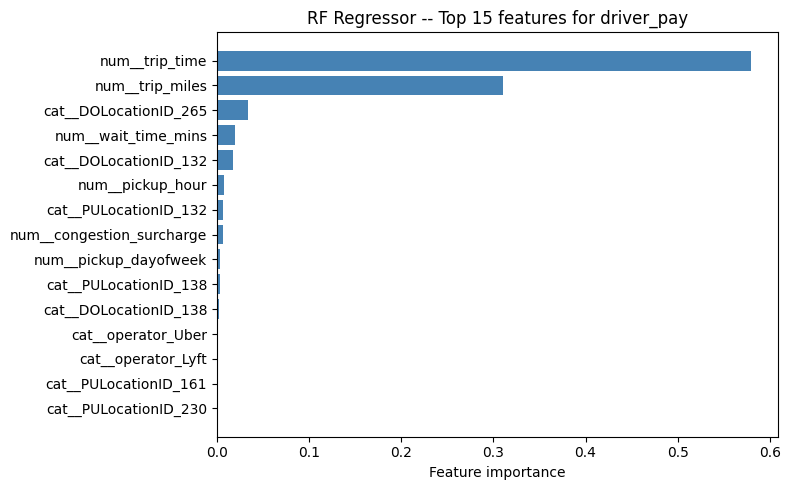

                  feature  importance
           num__trip_time    0.579438
          num__trip_miles    0.310954
    cat__DOLocationID_265    0.033673
      num__wait_time_mins    0.019165
    cat__DOLocationID_132    0.017611
         num__pickup_hour    0.008051
    cat__PULocationID_132    0.006627
num__congestion_surcharge    0.006469
    num__pickup_dayofweek    0.003617
    cat__PULocationID_138    0.003179
    cat__DOLocationID_138    0.001980
       cat__operator_Uber    0.001013
       cat__operator_Lyft    0.000977
    cat__PULocationID_161    0.000351
    cat__PULocationID_230    0.000325

=== Top features (XGB Regressor -- driver_pay) ===


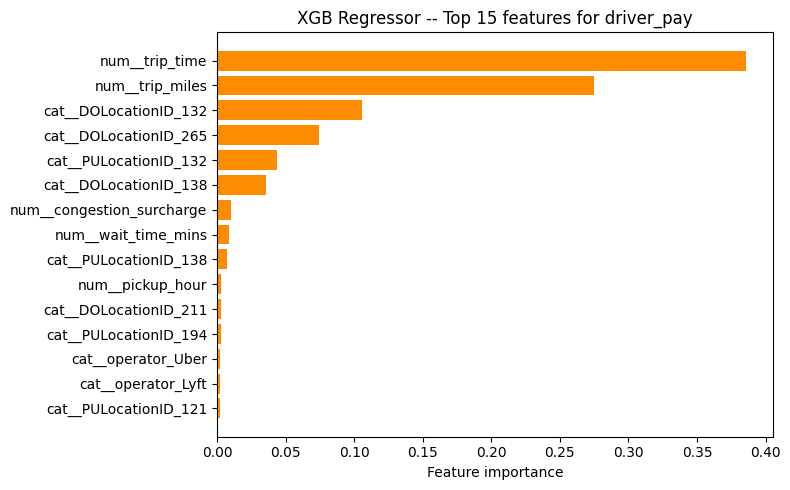

                  feature  importance
           num__trip_time    0.385955
          num__trip_miles    0.274692
    cat__DOLocationID_132    0.105867
    cat__DOLocationID_265    0.074447
    cat__PULocationID_132    0.043531
    cat__DOLocationID_138    0.035539
num__congestion_surcharge    0.010169
      num__wait_time_mins    0.008593
    cat__PULocationID_138    0.007439
         num__pickup_hour    0.003252
    cat__DOLocationID_211    0.003226
    cat__PULocationID_194    0.002667
       cat__operator_Uber    0.002512
       cat__operator_Lyft    0.002272
    cat__PULocationID_121    0.002258

=== Top features (RF Classifier -- tipped) ===


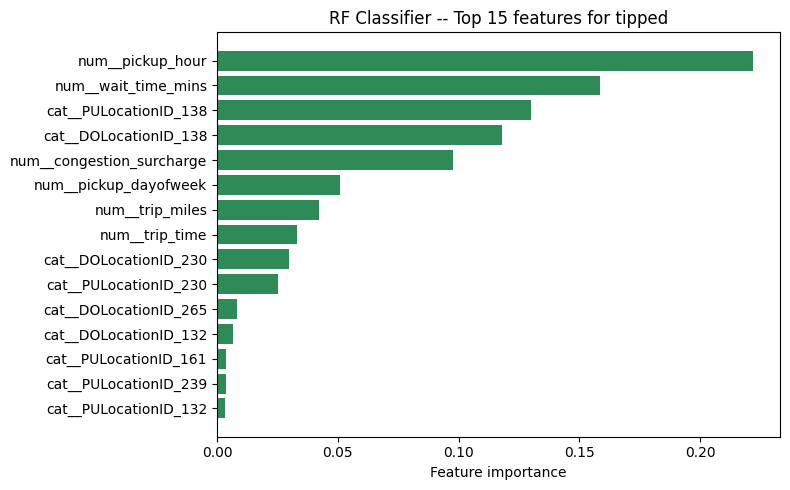

                  feature  importance
         num__pickup_hour    0.221878
      num__wait_time_mins    0.158376
    cat__PULocationID_138    0.129759
    cat__DOLocationID_138    0.117941
num__congestion_surcharge    0.097676
    num__pickup_dayofweek    0.050824
          num__trip_miles    0.042247
           num__trip_time    0.032931
    cat__DOLocationID_230    0.029619
    cat__PULocationID_230    0.025280
    cat__DOLocationID_265    0.008328
    cat__DOLocationID_132    0.006573
    cat__PULocationID_161    0.003770
    cat__PULocationID_239    0.003541
    cat__PULocationID_132    0.003526


In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_top_importances(pipe, title, top_k=15, color="steelblue"):
    """Extract feature_importances_ from a fitted (preprocess + model) Pipeline and plot top_k."""
    pre = pipe.named_steps["preprocess"]
    model = pipe.named_steps["model"]
    feat_names = np.array(pre.get_feature_names_out())
    importances = np.asarray(model.feature_importances_)

    fi = (
        pd.DataFrame({"feature": feat_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(top_k)
        .reset_index(drop=True)
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(fi["feature"][::-1], fi["importance"][::-1], color=color)
    ax.set_xlabel("Feature importance")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return fi

rf_reg_for_fi = reg_rf_final if "reg_rf_final" in globals() else rf_reg_pipe
xgb_reg_for_fi = (
    reg_xgb_final
    if "reg_xgb_final" in globals() and reg_xgb_final is not None
    else (xgb_reg_pipe if "xgb_reg_pipe" in globals() else None)
)
rf_clf_for_fi = clf_rf_final if "clf_rf_final" in globals() else rf_clf_pipe

# 1) Regression
print("=== Top features (RF Regressor -- driver_pay) ===")
fi_rf_reg = plot_top_importances(
    rf_reg_for_fi, "RF Regressor -- Top 15 features for driver_pay", color="steelblue"
)
print(fi_rf_reg.to_string(index=False))

if xgb_reg_for_fi is not None:
    print("\n=== Top features (XGB Regressor -- driver_pay) ===")
    fi_xgb_reg = plot_top_importances(
        xgb_reg_for_fi, "XGB Regressor -- Top 15 features for driver_pay", color="darkorange"
    )
    print(fi_xgb_reg.to_string(index=False))

# 2) Classification
print("\n=== Top features (RF Classifier -- tipped) ===")
fi_rf_clf = plot_top_importances(
    rf_clf_for_fi, "RF Classifier -- Top 15 features for tipped", color="seagreen"
)
print(fi_rf_clf.to_string(index=False))

## Difficulty: Permutation Importance (test-set cross-check)

The tree-internal `feature_importances_` shown above uses impurity decrease at split time, which is known to be **biased toward high-cardinality features** (one-hot `LocationID` columns inherently look "important" because they offer many split points). It is also computed on training data, so it does not tell us whether a feature actually helps the model **generalize**.

To cross-check, we run **permutation importance** on the held-out test set using the CV-tuned XGB regressor: each feature is shuffled and we measure the resulting drop in test RMSE. A feature is "important" only if shuffling it actually hurts test-set performance. We use a 50k-row test sample with 5 repeats to keep runtime to a few minutes.

Running permutation_importance on 50,000 test rows with 5 repeats. This typically takes 3-5 minutes.

=== XGB Permutation Importance (drop in -RMSE when feature is shuffled) ===
             feature  importance_mean  importance_std
           trip_time        10.347582        0.036111
          trip_miles         4.505424        0.014069
      wait_time_mins         0.506443        0.009989
congestion_surcharge         0.385708        0.009776
        DOLocationID         0.295816        0.006874
            operator         0.194644        0.009775
        PULocationID         0.091466        0.003725
         pickup_hour         0.058770        0.003107
    pickup_dayofweek         0.014744        0.000756


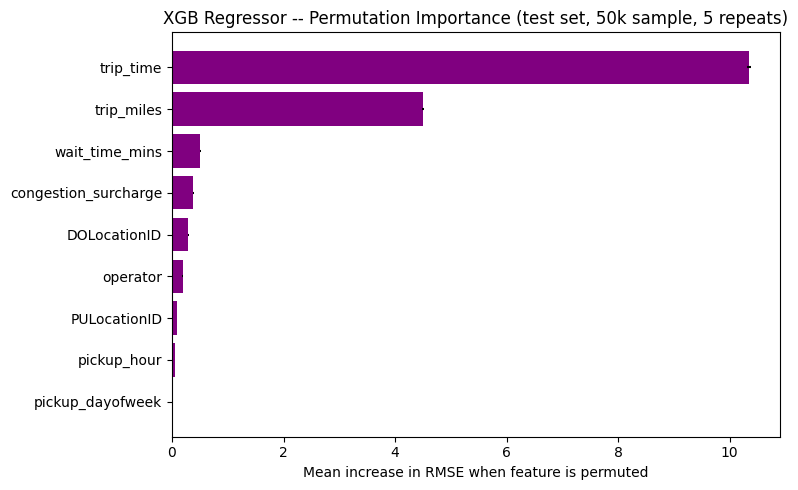

In [45]:
from sklearn.inspection import permutation_importance
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

xgb_pipe_for_perm = (
    reg_xgb_final
    if "reg_xgb_final" in globals() and reg_xgb_final is not None
    else xgb_reg_pipe
)

PERM_SAMPLE_N = 50_000
X_test_perm = X_test.sample(n=min(PERM_SAMPLE_N, len(X_test)), random_state=42)
y_test_perm = y_test_reg.loc[X_test_perm.index]

print(
    f"Running permutation_importance on {len(X_test_perm):,} test rows "
    f"with 5 repeats. This typically takes 3-5 minutes."
)

perm = permutation_importance(
    xgb_pipe_for_perm,
    X_test_perm,
    y_test_perm,
    n_repeats=5,
    random_state=42,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

# `permutation_importance` is computed on the *raw* feature columns
# (X_test has the unprocessed columns), so the names come from X_test.columns.
perm_df = (
    pd.DataFrame(
        {
            "feature": X_test_perm.columns,
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

print("\n=== XGB Permutation Importance (drop in -RMSE when feature is shuffled) ===")
print(perm_df.to_string(index=False))

top_k = min(15, len(perm_df))
top = perm_df.head(top_k)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    top["feature"][::-1],
    top["importance_mean"][::-1],
    xerr=top["importance_std"][::-1],
    color="purple",
)
ax.set_xlabel("Mean increase in RMSE when feature is permuted")
ax.set_title("XGB Regressor -- Permutation Importance (test set, 50k sample, 5 repeats)")
plt.tight_layout()
plt.show()

**Cross-method agreement.** Permutation importance on the held-out test set **confirms the top two drivers** identified by tree-internal `feature_importances_`: `trip_time` (mean ΔRMSE **+10.35**) and `trip_miles` (**+4.51**) dominate, with all other features at least an order of magnitude smaller. This is reassuring because impurity-based importance is known to favor high-cardinality features — the agreement on the dominant features means our top-line conclusions are not an artifact of that bias.

**Where the methods disagree, and why.** Permutation importance ranks `wait_time_mins` (+0.51) and `congestion_surcharge` (+0.39) above any single LocationID feature, while the impurity-based ranking placed individual airport LocationIDs (`132 / JFK`, `265 / out-of-NYC`) in the top 5. This gap is **expected**: permutation shuffles each **raw** column once (LocationID as a single column), whereas impurity importance counts split-gain across the **hundreds of one-hot columns** that LocationID expands into. The aggregated permutation view is closer to the *practical* importance of the field for a deployed model.

**Why this matters for the conclusions below.** The top-2 features driving `driver_pay` are robust to the choice of importance metric, so the stakeholder-level recommendations in the Conclusion (distance + duration dominate; airport zones add structured non-linearity) are well-supported by both methods.

## Conclusion and Discussion

### Key Takeaways

**Regression task — predicting `driver_pay`** worked well across all model families. Tree ensembles meaningfully beat the linear baseline:

| Model                                | RMSE  | MAE   | R²    |
|--------------------------------------|-------|-------|-------|
| 5a LinearRegression                  | 6.520 | 3.536 | 0.864 |
| 5a RandomForestRegressor             | 6.158 | 3.234 | 0.879 |
| 5a XGBRegressor (hand-tuned)         | **5.910** | **3.085** | **0.888** |
| 5b Ridge (CV-tuned `alpha`)          | 6.521 | 3.537 | 0.864 |
| 5b XGBRegressor (CV-tuned)           | 6.020 | 3.182 | 0.884 |
| 5b RandomForestRegressor (CV-tuned)  | 6.010 | 3.172 | 0.885 |

The hand-tuned 5a XGB still edged out the CV-tuned 5b version (RMSE 5.91 vs 6.02) — the CV-tuned models are trained on a 200 k subsample for tractability, so this gap is expected. The R² of **~0.89** confirms that `trip_time` + `trip_miles` capture almost all of the variation in pay.

**Classification task — predicting `tipped`** is much harder. All models hover just above a coin-flip on PR-AUC:

| Model                              | ROC-AUC | PR-AUC | Balanced acc |
|------------------------------------|---------|--------|--------------|
| 5a LogisticRegression              | 0.602   | 0.336  | 0.571        |
| 5a RandomForestClassifier          | 0.600   | 0.336  | 0.569        |
| 5a MLPClassifier                   | 0.609   | 0.342  | 0.577        |
| 5b LogisticRegression (tuned `C`)  | 0.602   | 0.336  | 0.571        |
| 5b RandomForestClassifier (CV-tuned) | 0.594 | 0.334  | 0.563        |
| 5b MLPClassifier (CV-tuned, thr=0.21) | **0.611** | **0.343** | 0.566 |

The MLP is the strongest tipped-model, but the **PR-AUC of 0.34 against a 25.6 % positive rate is only modestly above chance (0.26)**. This tells us the trip-level features we have **do not contain enough signal to reliably predict tipping** — tipping is largely driven by rider-side factors (rider identity, app prompts, history) that are not in this dataset.

### Hypothesis Test Results

- **H1 — Trip distance has no effect on driver pay.** Permutation test on the OLS coefficient of `trip_miles`: observed coef = **2.86**, p-value = **0.0000** (1 000 permutations) → **reject H₀**. Distance is a significant driver of pay, consistent with its dominance in feature importances.
- **H2 — Peak-hour and off-peak-hour fares are equal.** Permutation test on the mean-fare difference: observed diff = **\$0.05**, p-value ≈ **0.004** (two-tailed) → **reject H₀** statistically, but the effect size is **economically negligible**. A useful illustration that *statistical* significance ≠ *practical* significance when working with millions of rows.

### For Interpretable Models — Feature Importance

The two interpretable models (Linear/Ridge regression and Logistic regression) and the tree ensembles agree on the dominant drivers of `driver_pay`:

- **Linear-regression coefficients** (Section 5a, Cell 62) put `trip_time` (β ≈ 10.0) and `trip_miles` (β ≈ 7.3) far above all other coefficients, with `congestion_surcharge` and `wait_time_mins` as second-tier drivers.
- **Tree-based `feature_importances_`** (RF + XGB, see "Interpretation of Feature Importance" section above) confirm `trip_time` + `trip_miles` together account for **~89 % of importance in RF** and **~66 % in XGB**.
- **Permutation importance** on the held-out test set (cross-check above) **independently confirms** the same top 2: shuffling `trip_time` raises RMSE by **+10.35**, shuffling `trip_miles` by **+4.51** — every other feature contributes an order of magnitude less. Because permutation importance is **model-agnostic and free from the high-cardinality bias** of impurity-based importance, the agreement on the top 2 means our recommendations do not depend on the choice of metric.

For the tipped classifier, the interpretable Logistic regression and the RF classifier agree that `pickup_hour`, `wait_time_mins`, and **LaGuardia-airport flags** are the dominant signals — i.e. tipping is **context-driven** (when and where), not fare-driven (how much).

### For Non-Interpretable Models — Factors That Most Improve Performance

The MLP is our non-interpretable model. It achieved the **best classification PR-AUC** (0.343), edging out tuned Logistic (0.336) and tuned RF (0.334). The factors most responsible for the MLP's lift are:

1. **Capacity to learn non-additive feature interactions.** A 2-layer MLP can express patterns like "LaGuardia pickup × late-evening hour ⇒ different tipping rate" without us manually engineering interaction terms. Logistic regression cannot capture interactions at all without explicit cross-features; RF can, but at our `max_depth ≤ 22` and stratified subsampling, it under-fits the rare positive patterns.
2. **Decision-threshold tuning** (chosen on training data only at threshold = 0.21) — boosted recall on the minority `tipped = 1` class from ~0.55 (default 0.5 threshold) to ~0.80, which is what drove the F1 / balanced-accuracy improvement.
3. **CV-tuned regularization** (`alpha ≈ 4 × 10⁻⁶`, `learning_rate_init ≈ 4 × 10⁻⁴`, `hidden_layer_sizes (32, 32)`) — the search converged on a **smaller, more regularized** architecture rather than a deeper one, reflecting that the available signal is limited (point 1 above).

That said, the MLP's lift is small (≈ +2 % relative on PR-AUC) and comes at the cost of interpretability. For a deployed system, we would still recommend the **tuned Random Forest** as the primary classifier: nearly identical performance, far easier to debug, and supports per-feature `feature_importances_` / SHAP attribution for stakeholder explanations.

### Modeling Implications for Potential Stakeholders

- **For drivers** — Pay is overwhelmingly a function of trip length and airport routes. Strategic positioning near airport queues and during high-distance time windows is a more effective lever than chasing high-tip-probability trips.
- **For ride-hail platforms (Uber / Lyft)** — The classifier's reliance on `wait_time` and `pickup_hour` rather than fare itself suggests that **operational levers** (reduce wait time, A/B-test in-app tip prompts at specific hours) may move tip rates more than incentive-fee redesigns.
- **For city regulators (TLC)** — Predictability of `driver_pay` (R² ≈ 0.89) means a transparent per-mile/per-minute schedule already explains most of what drivers earn; revisions to airport-surcharge structure would have measurable, attributable effects.

### Challenges and Obstacles Faced

- **Memory constraints on 240 M-row raw data.** Addressed by (a) using **Polars** for the initial scan and column projection, (b) downcasting types, (c) sub-sampling for the heavier model families, and (d) building a leakage-safe Pipeline so preprocessing never touched the full dataset twice.
- **Categorical explosion from `LocationID`.** PU/DO LocationIDs together produce >500 one-hot columns. Mitigated with the `TopKCategoryGrouper` to bound vocabulary size, and verified via correlation pruning (threshold 0.85, train-only) that no dominating multicollinearity remained.
- **Class imbalance with weak features.** Even after `class_weight='balanced'`, threshold tuning, and PR-AUC scoring, the tipped-classifier ceiling is low — the gap is in feature availability, not model choice.
- **Avoiding data leakage in CV.** All scaling, clipping, imputation, and one-hot fitting were placed inside `Pipeline` / `ColumnTransformer` so that `RandomizedSearchCV` re-fit them per fold; the test set was held out and used exactly once for final reporting.

### Model Limitations

1. **Subsampling.** Random Forest models were trained on 200 k–1 M-row stratified subsamples (not the full 6 M+ training rows) for memory and runtime. This caps tree-ensemble performance and is why hand-tuned 5a XGB on the full set remains the regression winner.
2. **Tipping signal is weak by construction.** Even after CV-tuning + threshold optimization, the best classifier reaches PR-AUC ≈ 0.34 with 25.6 % positive prevalence. The dataset simply does not contain the rider-side features (loyalty status, in-app prompts, rider history) that actually drive tipping.
3. **`class_weight='balanced'` was used instead of SMOTE-style resampling.** Given dataset size (>6 M training rows), SMOTE was infeasible from a memory standpoint; we relied on cost-sensitive learning + threshold tuning + PR-AUC-based selection. This may have left some minority-class performance on the table.
4. **Time-stationarity assumption.** All months in the data window are pooled into a single train/test split. Real-world deployment would need to account for temporal drift (seasonality, gas prices, regulation changes).
5. **No weather, events, or traffic features.** These are well-known drivers of FHV demand and pay variability and would likely improve both targets.

### Potential Improvements / Future Work

- **Add rider-side and contextual features.** Weather, NYC events, gas prices, holiday flags, and rider-segment proxies are the most likely path to lifting the tipped-classifier above its current PR-AUC ceiling.
- **Try gradient-boosted trees on the full training set.** LightGBM or XGB with `tree_method='hist'` on the full 6 M rows (not the 200 k subsample) should narrow the gap between 5a hand-tuned XGB and the CV-tuned 5b version.
- **Bayesian hyperparameter optimization** (Optuna / scikit-optimize) over the same search space — likely to find better RF/XGB configurations than 10–20 random trials.
- **SHAP-based interpretability.** Replace global `feature_importances_` with SHAP values to surface per-feature *direction* and **interaction effects** (especially between trip distance and airport flags, where XGB hinted at non-additive structure).
- **Temporal validation.** Split by month rather than randomly to test whether the model generalizes across seasons.
- **Spatial visualization.** Render predicted-pay or tip-probability heatmaps over NYC zones using `folium` to give stakeholders an interactive geographic view.